In [ ]:
!pip install cafaeval
#!pip install tensorflow
#!pip install keras

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 kB 3.0 MB/s eta 0:00:00


In [ ]:
!pip install Bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.3/321.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Bio.Seq import Seq
from Bio import SeqIO
from Bio import Align
from Bio import AlignIO
from Bio.Align import substitution_matrices
from Bio.Data import IUPACData
from Bio.Blast import NCBIWWW, NCBIXML
from Bio.SeqRecord import SeqRecord
from Bio import pairwise2
from Bio.pairwise2 import format_alignment
from pathlib import Path
import os
import h5py
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import ast
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model
from sklearn.metrics import precision_recall_fscore_support, f1_score, average_precision_score

/usr/local/lib/python3.12/dist-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [ ]:
# Mount your personal Google drive
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
training_data_path = Path('drive/MyDrive/BD/biological_data_pfp/train')

test_data_path = Path('drive/MyDrive/BD/biological_data_pfp/test')

baseline_data_path = Path('.drive/MyDrive/BD/biological_data_pfp/baseline')

# Training set creation:


*   Ectracting the data from the files
*   putting together a coherent DF



In [ ]:
train_set = pd.read_csv(training_data_path / 'train_set.tsv', sep='\t')

train_set.rename(columns={'Protein_ID': 'ID', 'aspect' : 'sub_ontology'}, inplace=True)

train_set.head()

,ID,sub_ontology,GO_term
0,P91124,cellular_component,GO:0005575
1,P91124,cellular_component,GO:0110165
2,P91124,cellular_component,GO:0005737
3,P91124,cellular_component,GO:0005622
4,P91124,cellular_component,GO:0043226


In [ ]:
# Extracting train_ids.txt
with open(training_data_path / 'train_ids.txt', 'r') as file:
    train_ids = file.read().splitlines()

print(train_ids[:5])

['P91124', 'Q55DL5', 'O81027', 'Q04418', 'Q8IXT2']


In [ ]:
if len(train_ids) == len(train_set['ID'].unique()):
    print(f"The number of IDs in train_ids.txt is equal to the number of unique IDs in the train set ({len(train_ids)}).\n"
          "Proceeding with the analysis.")

The number of IDs in train_ids.txt is equal to the number of unique IDs in the train set (123969).
Proceeding with the analysis.


# extrancting embeddings

In [ ]:
filename = "train_embeddings.h5"

data_list = []

with h5py.File(training_data_path / filename, "r") as f:
    for dataset_name in f.keys():
        dataset = f[dataset_name][:]
        data_list.append([dataset_name, dataset])

train_embeddings = pd.DataFrame(data_list, columns=["ID", "embeddings"])

train_embeddings.head()

,ID,embeddings
0,A0A009IHW8,"[0.0682, -0.04648, 0.001752, -0.00858, 0.00376..."
1,A0A021WW32,"[-0.01643, -0.001583, 0.00389, 0.0734, 0.01243..."
2,A0A021WZA4,"[0.007904, 0.0877, -0.001715, 0.03766, 0.01788..."
3,A0A023FBW4,"[0.002447, 0.007053, 0.06445, 0.00727, -0.0335..."
4,A0A023FBW7,"[0.04932, 0.02069, 0.10864, 0.01634, -0.05106,..."


In [ ]:
train_protein2ipr = pd.read_csv(training_data_path / 'train_protein2ipr.dat', sep='\t')

# Rename Protein_ID and aspect columns
train_protein2ipr.columns = ['ID', 'ipr', 'domain', 'familyID', 'start', 'end']

train_protein2ipr.head()

,ID,ipr,domain,familyID,start,end
0,A0A009IHW8,IPR000157,Toll/interleukin-1 receptor homology (TIR) domain,PS50104,133,266
1,A0A009IHW8,IPR000157,Toll/interleukin-1 receptor homology (TIR) domain,SM00255,134,258
2,A0A009IHW8,IPR035897,Toll/interleukin-1 receptor homology (TIR) dom...,G3DSA:3.40.50.10140,80,266
3,A0A009IHW8,IPR035897,Toll/interleukin-1 receptor homology (TIR) dom...,SSF52200,128,249
4,A0A021WW32,IPR006910,"Rad21/Rec8-like protein, N-terminal",PF04825,1,103


In [ ]:
# Group by 'ID' and aggregate other columns into lists
train_protein2ipr_grouped = train_protein2ipr.groupby('ID').agg(lambda x: tuple(x)).reset_index()

print(f"Train protein2ipr ({train_protein2ipr.shape}):")
train_protein2ipr_grouped.head()

Train protein2ipr ((1103545, 6)):


,ID,ipr,domain,familyID,start,end
0,A0A009IHW8,"(IPR000157, IPR000157, IPR035897, IPR035897)",(Toll/interleukin-1 receptor homology (TIR) do...,"(PS50104, SM00255, G3DSA:3.40.50.10140, SSF52200)","(133, 134, 80, 128)","(266, 258, 266, 249)"
1,A0A021WW32,"(IPR006910, IPR039781, IPR049589)","(Rad21/Rec8-like protein, N-terminal, Rad21/Re...","(PF04825, PTHR12585, cd21792)","(1, 1, 327)","(103, 607, 404)"
2,A0A021WZA4,"(IPR004481, IPR004481, IPR004837, IPR004837, I...","(Sodium/potassium/calcium exchanger, Sodium/po...","(PTHR10846, TIGR00367, PF01699, PF01699, G3DSA...","(6, 31, 33, 329, 64, 286)","(496, 476, 175, 480, 258, 482)"
3,A0A023FBW7,"(IPR045797,)","(Evasins Class A,)","(PF19429,)","(38,)","(110,)"
4,A0A023FDY8,"(IPR045797,)","(Evasins Class A,)","(PF19429,)","(38,)","(110,)"


In [ ]:
import re

file_path = training_data_path /"go-basic.obo"  #set right path

# storage for GO terms
go_terms = []

# Parse the .obo file
with open(file_path, 'r') as file:
    current_term = {}
    for line in file:
        line = line.strip()

        # Start of a new term
        if line == "[Term]":
            if current_term:  # Save the previous term
                go_terms.append(current_term)
            current_term = {}  # Start a new term

        elif line.startswith("id:"):
            current_term['ID'] = line.split("id: ")[1]

        elif line.startswith("alt_id:"):
            alt_id = line.split("alt_id: ")[1]
            current_term.setdefault('alt_ids', []).append(alt_id)

        elif line.startswith("name:"):
            current_term['name'] = line.split("name: ")[1]

        elif line.startswith("namespace:"):
            current_term['namespace'] = line.split("namespace: ")[1]

        elif line.startswith("is_a"):
            match = re.search(r"GO:\d+", line)  # Search for GO ID
            if match:  # Check if a match was found
                is_a_id = match.group()
                current_term.setdefault('is_a', []).append(is_a_id)

        elif line.startswith("relationship: part_of"):
            match = re.search(r"GO:\d+", line)  # Search for GO ID
            if match:  # Check if a match was found
                part_of_id = match.group()
                current_term.setdefault('part_of', []).append(part_of_id)


    # Add the last term
    if current_term:
        go_terms.append(current_term)

# unified list of all IDs (primary and alt_ids)
expanded_terms = []
for term in go_terms:
    primary_id = term['ID']
    alt_ids = term.get('alt_ids', [])
    all_ids = [primary_id] + alt_ids

    for term_id in all_ids:
        expanded_terms.append({
            'ID': term_id,
            'name': term.get('name'),
            'namespace': term.get('namespace'),
            'is_a': term.get('is_a', []),
            'part_of': term.get('part_of', [])
        })

# Convert to a DataFrame
df = pd.DataFrame(expanded_terms)

# Filter by namespace and explode relationships
df_is_a = df.explode('is_a').dropna(subset=['is_a'])
df_part_of = df.explode('part_of').dropna(subset=['part_of'])


print("All IDs with namespaces:")
df.head()

All IDs with namespaces:


,ID,name,namespace,is_a,part_of
0,GO:0000001,mitochondrion inheritance,biological_process,"[GO:0048308, GO:0048311]",[]
1,GO:0000002,mitochondrial genome maintenance,biological_process,[GO:0007005],[]
2,GO:0000003,reproduction,biological_process,[GO:0008150],[]
3,GO:0019952,reproduction,biological_process,[GO:0008150],[]
4,GO:0050876,reproduction,biological_process,[GO:0008150],[]









*  train_set.tsv Contains the proteins, their GO annotations, and their corresponding aspects. These aspects will be used to subdivide the data into three separate datasets.

*   train_protein2ipr.dat Contains the mapping information for protein InterPro domains.
*   go-basic.obo Contains the fundamental Gene Ontology structure and definitions.





In [ ]:
def aggregate_terms_by_aspect(dataset, aspect_name):
    """
    Aggregates GO terms by aspect (CC, MF, BP).
    """
    # filter rows for sub ontology
    subset = dataset[dataset['sub_ontology'] == aspect_name]

    # gurups ID and aggragate terms
    return subset.groupby('ID')['GO_term'].apply(tuple).reset_index()

# aggragate DF creation (CC, MF, BP)
train_cc = aggregate_terms_by_aspect(train_set, 'cellular_component')
train_mf = aggregate_terms_by_aspect(train_set, 'molecular_function')
train_bp = aggregate_terms_by_aspect(train_set, 'biological_process')

# dimension check
print(f"Shapes -> CC: {train_cc.shape}, MF: {train_mf.shape}, BP: {train_bp.shape}")

print(f"Cellular Component (samples: {train_cc.shape[0]}):")
train_mf.head()

Shapes -> CC: (84638, 2), MF: (55698, 2), BP: (83064, 2)
Cellular Component (samples: 84638):


,ID,GO_term
0,A0A009IHW8,"(GO:0016798, GO:0003824, GO:0016799, GO:001678..."
1,A0A023FBW4,"(GO:0005515, GO:0019955, GO:0019956, GO:000367..."
2,A0A023FBW7,"(GO:0005515, GO:0019955, GO:0019956, GO:000367..."
3,A0A023FDY8,"(GO:0005515, GO:0019955, GO:0019956, GO:000367..."
4,A0A023FF81,"(GO:0005515, GO:0019955, GO:0019956, GO:000367..."


In [ ]:
#combined_train = pd.merge(train_embeddings, train_fasta, on='ID')
combined_train = pd.merge(train_embeddings, train_protein2ipr_grouped, on='ID', how='left')

missing_rows = combined_train[combined_train['ipr'].isna()].shape[0]
print(f"Number of rows missing from train_protein2ipr_grouped: {missing_rows}")

print(f"Combined DataFrame shape: {combined_train.shape}")
combined_train.head()

Number of rows missing from train_protein2ipr_grouped: 6522
Combined DataFrame shape: (123969, 7)


,ID,embeddings,ipr,domain,familyID,start,end
0,A0A009IHW8,"[0.0682, -0.04648, 0.001752, -0.00858, 0.00376...","(IPR000157, IPR000157, IPR035897, IPR035897)",(Toll/interleukin-1 receptor homology (TIR) do...,"(PS50104, SM00255, G3DSA:3.40.50.10140, SSF52200)","(133, 134, 80, 128)","(266, 258, 266, 249)"
1,A0A021WW32,"[-0.01643, -0.001583, 0.00389, 0.0734, 0.01243...","(IPR006910, IPR039781, IPR049589)","(Rad21/Rec8-like protein, N-terminal, Rad21/Re...","(PF04825, PTHR12585, cd21792)","(1, 1, 327)","(103, 607, 404)"
2,A0A021WZA4,"[0.007904, 0.0877, -0.001715, 0.03766, 0.01788...","(IPR004481, IPR004481, IPR004837, IPR004837, I...","(Sodium/potassium/calcium exchanger, Sodium/po...","(PTHR10846, TIGR00367, PF01699, PF01699, G3DSA...","(6, 31, 33, 329, 64, 286)","(496, 476, 175, 480, 258, 482)"
3,A0A023FBW4,"[0.002447, 0.007053, 0.06445, 0.00727, -0.0335...",NaN,NaN,NaN,NaN,NaN
4,A0A023FBW7,"[0.04932, 0.02069, 0.10864, 0.01634, -0.05106,...","(IPR045797,)","(Evasins Class A,)","(PF19429,)","(38,)","(110,)"




*   Adding embeddings and sequence info to the 3 dataset devided by sub-ontholgy




In [ ]:
# Merge combined_train with train_xx
train_CC_full= pd.merge(combined_train, train_cc, on='ID', how='right')
train_MF_full= pd.merge(combined_train, train_mf, on='ID', how='right')
train_BP_full= pd.merge(combined_train, train_bp, on='ID', how='right')

print(f"Shapes: CC {train_CC_full.shape}, MF {train_MF_full.shape}, BP {train_BP_full.shape}")

print(f"Full df CC {train_CC_full.shape}:")
train_CC_full.head()

Shapes: CC (84638, 8), MF (55698, 8), BP (83064, 8)
Full df CC (84638, 8):


,ID,embeddings,ipr,domain,familyID,start,end,GO_term
0,A0A021WW32,"[-0.01643, -0.001583, 0.00389, 0.0734, 0.01243...","(IPR006910, IPR039781, IPR049589)","(Rad21/Rec8-like protein, N-terminal, Rad21/Re...","(PF04825, PTHR12585, cd21792)","(1, 1, 327)","(103, 607, 404)","(GO:0005575, GO:0110165, GO:0000785, GO:003299..."
1,A0A021WZA4,"[0.007904, 0.0877, -0.001715, 0.03766, 0.01788...","(IPR004481, IPR004481, IPR004837, IPR004837, I...","(Sodium/potassium/calcium exchanger, Sodium/po...","(PTHR10846, TIGR00367, PF01699, PF01699, G3DSA...","(6, 31, 33, 329, 64, 286)","(496, 476, 175, 480, 258, 482)","(GO:0005575, GO:0110165, GO:0071944, GO:000588..."
2,A0A023GPJ3,"[0.01512, 0.01102, 0.0217, -0.02512, 0.0396, 0...","(IPR013087, IPR013087, IPR013087, IPR013087, I...","(Zinc finger C2H2-type, Zinc finger C2H2-type,...","(PF00096, PF00096, PF00096, PF00096, PS00028, ...","(644, 956, 983, 1013, 197, 646, 674, 957, 985,...","(666, 977, 1005, 1034, 218, 666, 694, 977, 100...","(GO:0005575, GO:0110165, GO:0005622, GO:000582..."
3,A0A023GUT0,"[-0.00414, -0.01288, 0.0716, 0.01605, -0.03983...","(IPR000065, IPR000065, IPR009079, IPR009079)","(Leptin, Leptin, Four-helical cytokine-like, c...","(PF02024, PTHR11724, G3DSA:1.20.1250.10, SSF47...","(28, 7, 24, 29)","(172, 172, 172, 172)","(GO:0005575, GO:0110165, GO:0005576, GO:0005615)"
4,A0A023IM54,"[-0.01651, 0.02525, 0.04333, 0.01558, -0.01678...","(IPR003006, IPR003597, IPR003597, IPR007110, I...",(Immunoglobulin/major histocompatibility compl...,"(PS00290, PF07654, SM00407, PS50835, PR01669, ...","(382, 312, 312, 294, 55, 135, 199, 247, 271, 3...","(388, 391, 394, 401, 63, 146, 216, 261, 287, 3...","(GO:0005575, GO:0005737, GO:0042175, GO:003299..."


# Analysis


*   labels
*   controllare metriche




==================== ANALYSIS: CELLULAR COMPONENT ====================
Total unique terms: 678
Min frequency: 49
Max frequency: 84638
Median frequency: 203.0

--- Threshold Check (50) ---
Rare term examples: ['GO:0031941']


/tmp/ipython-input-1193634499.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=term_counts.head(50).values, y=term_counts.head(50).index, ax=axes[0], palette="viridis")


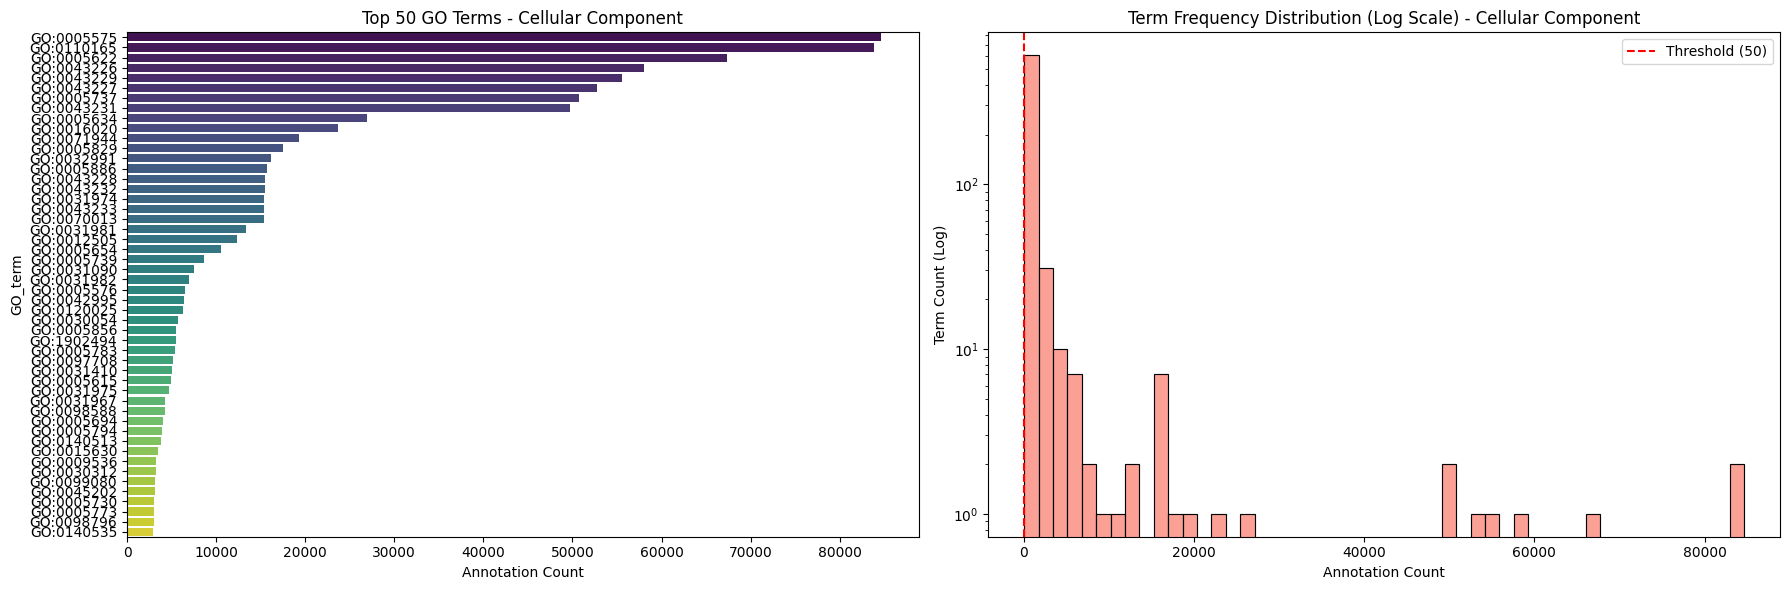


==================== ANALYSIS: MOLECULAR FUNCTION ====================
Total unique terms: 839
Min frequency: 48
Max frequency: 55698
Median frequency: 134.0

--- Threshold Check (50) ---
Rare term examples: ['GO:0070492', 'GO:0008556', 'GO:0043014', 'GO:0015038', 'GO:0010314']


/tmp/ipython-input-1193634499.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=term_counts.head(50).values, y=term_counts.head(50).index, ax=axes[0], palette="viridis")


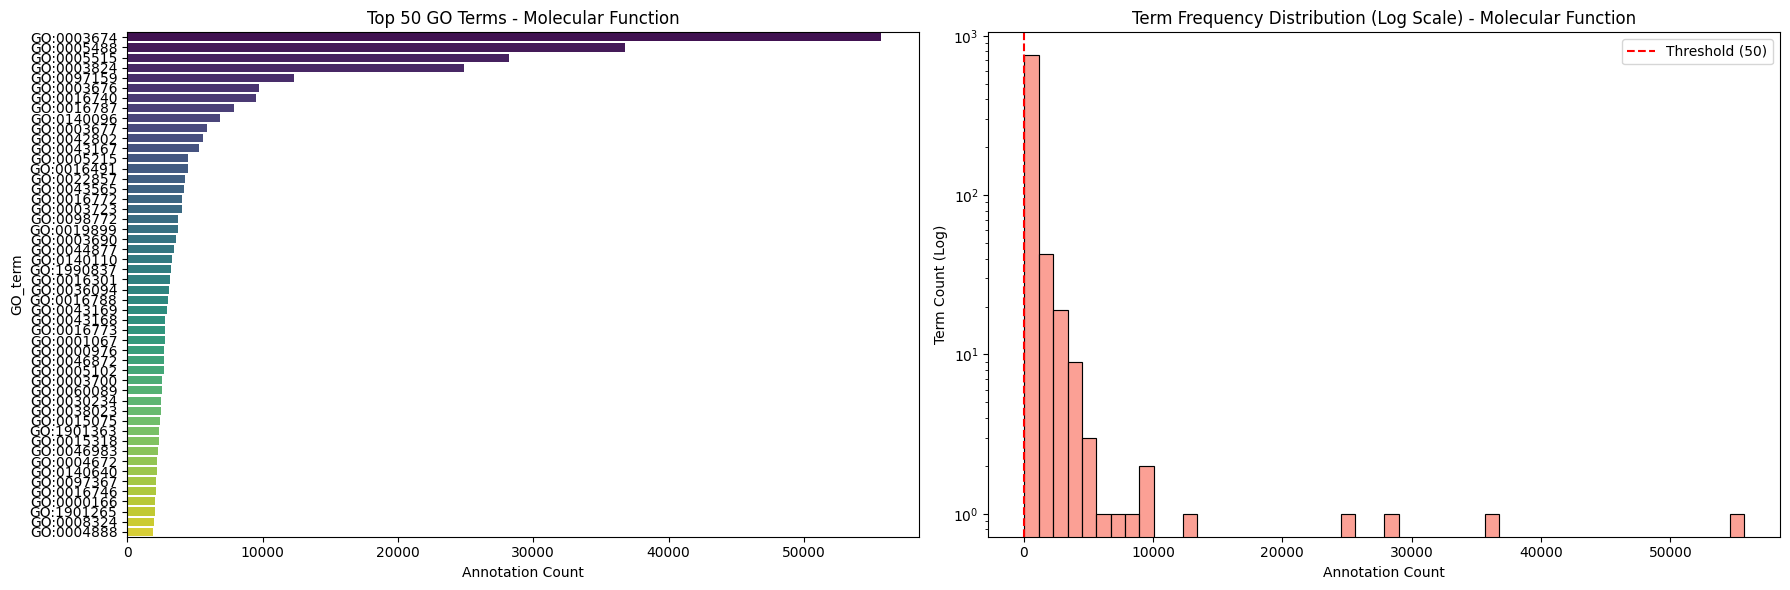


==================== ANALYSIS: BIOLOGICAL PROCESS ====================
Total unique terms: 1487
Min frequency: 238
Max frequency: 83064
Median frequency: 588.0

--- Threshold Check (250) ---
Rare term examples: ['GO:0070918', 'GO:0002250', 'GO:0051348', 'GO:0090090', 'GO:0007189']


/tmp/ipython-input-1193634499.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=term_counts.head(50).values, y=term_counts.head(50).index, ax=axes[0], palette="viridis")


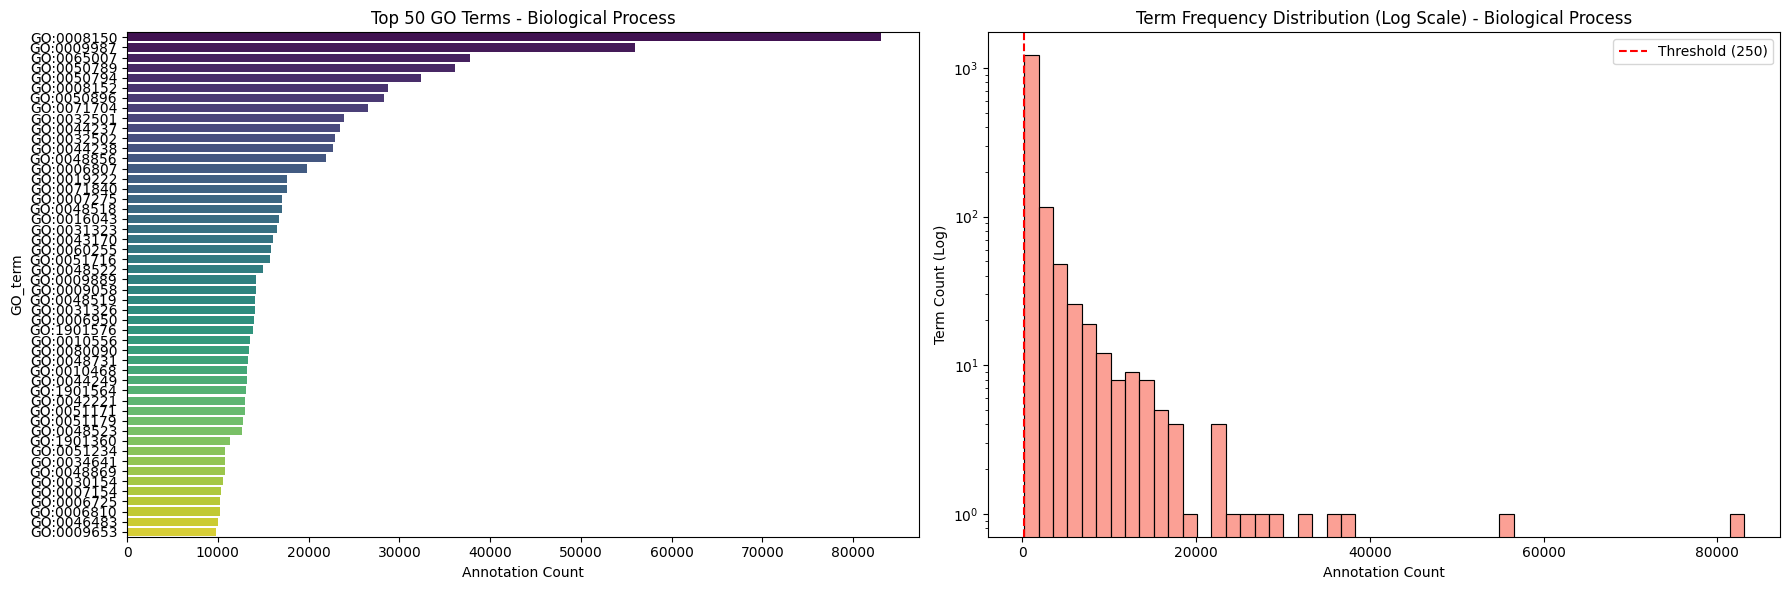

In [ ]:
def analyze_term_frequencies(df, ontology_name, threshold):
    """
    Analyzes GO term frequencies, plots distribution, and checks thresholds.
    """
    print(f"\n{'='*20} ANALYSIS: {ontology_name.upper()} {'='*20}")

    # 1. Explode the list of terms to count individual occurrences
    exploded_df = df.explode('GO_term')

    # 2. Count frequency of each term
    term_counts = exploded_df['GO_term'].value_counts()

    # Basic statistics
    num_unique_terms = len(term_counts)
    min_count = term_counts.min()
    max_count = term_counts.max()
    median_count = term_counts.median()

    print(f"Total unique terms: {num_unique_terms}")
    print(f"Min frequency: {min_count}")
    print(f"Max frequency: {max_count}")
    print(f"Median frequency: {median_count}")

    # 3. Threshold Check
    below_threshold = term_counts[term_counts < threshold]
    count_below = len(below_threshold)

    print(f"\n--- Threshold Check ({threshold}) ---")
    if count_below == 0:
        print(f"All terms meet the {threshold} instance threshold.")
    else:
        print(f"WARNING: {count_below} terms ({count_below/num_unique_terms:.1%}) are below threshold.")
        print(f"Rare term examples: {below_threshold.head(5).index.tolist()}")

    # 4. Visualization
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Plot 1: Top 20 most frequent terms
    sns.barplot(x=term_counts.head(50).values, y=term_counts.head(50).index, ax=axes[0], palette="viridis")
    axes[0].set_title(f'Top 50 GO Terms - {ontology_name}')
    axes[0].set_xlabel('Annotation Count')

    # Plot 2: Frequency distribution histogram (Log Scale)
    sns.histplot(term_counts.values, bins=50, kde=False, ax=axes[1], color="salmon")
    axes[1].set_yscale('log')
    axes[1].set_title(f'Term Frequency Distribution (Log Scale) - {ontology_name}')
    axes[1].set_xlabel('Annotation Count')
    axes[1].set_ylabel('Term Count (Log)')
    axes[1].axvline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold})')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return term_counts

# --- RUN ANALYSIS ---

# 1. Cellular Component (Threshold: 50)
freq_cc = analyze_term_frequencies(train_CC_full, 'Cellular Component', threshold=50)

# 2. Molecular Function (Threshold: 50)
freq_mf = analyze_term_frequencies(train_MF_full, 'Molecular Function', threshold=50)

# 3. Biological Process (Threshold: 250)
freq_bp = analyze_term_frequencies(train_BP_full, 'Biological Process', threshold=250)

# filtering for white noise

*   usefull from a ML poin of view, not ideal because of our task



In [ ]:
'''def filter_by_counts(df, term_counts, threshold):
    """
    Removes proteins that have no terms left after filtering.
    """
    initial_shape = df.shape

    # Identify valid terms
    valid_terms = set(term_counts[term_counts >= threshold].index)
    print(f"Keeping {len(valid_terms)} unique terms out of {len(term_counts)}.")

    # Filter the term lists for each protein
    df_filtered = df.copy()
    df_filtered['GO_term'] = df_filtered['GO_term'].apply(lambda terms: [t for t in terms if t in valid_terms])

    # Remove proteins that resulted in empty term lists
    #df_filtered = df_filtered[df_filtered['GO_term'].map(len) > 0]

    #print(f"Proteins removed (empty annotations): {initial_shape[0] - df_filtered.shape[0]}")
    #print(f"Final shape: {df_filtered.shape}\n")

    return df_filtered

# Cellular Component
print("--- FILTERING CELLULAR COMPONENT ---")
train_CC_final = filter_by_counts(train_CC_full, freq_cc, threshold=50)

# Molecular Function
print("--- FILTERING MOLECULAR FUNCTION ---")
train_MF_final = filter_by_counts(train_MF_full, freq_mf, threshold=50)

# Biological Process
print("--- FILTERING BIOLOGICAL PROCESS ---")
train_BP_final = filter_by_counts(train_BP_full, freq_bp, threshold=250)

SyntaxError: incomplete input (ipython-input-250248889.py, line 1)

In [ ]:
'''def filter_by_counts(df, term_counts, threshold, max_freq=0.98):
    """
    Rimuove i termini troppo rari (sotto 'threshold')
    E quelli troppo frequenti (sopra 'max_freq' * totale proteine).
    Infine rimuove le proteine rimaste senza annotazioni.
    """
    initial_shape = df.shape
    total_proteins = len(df)

    # Calcolo limite massimo (es. se appare in più del 98% delle proteine)
    upper_limit = total_proteins * max_freq

    # 1. Identifica i termini validi (Range: Min <= count <= Max)
    # Questa è la riga magica modificata:
    valid_terms = set(term_counts[
        (term_counts >= threshold) &
        (term_counts <= upper_limit)
    ].index)

    print(f"Termini mantenuti: {len(valid_terms)} su {len(term_counts)} "
          f"(Rimossi frequenti > {int(upper_limit)} occorrenze)")

    # 2. Filtra la lista dei termini per ogni riga
    df_filtered = df.copy()
    df_filtered['GO_term'] = df_filtered['GO_term'].apply(lambda terms: [t for t in terms if t in valid_terms])

    # 3. Rimuovi le proteine che hanno lista vuota dopo il filtro
    df_filtered = df_filtered[df_filtered['GO_term'].map(len) > 0]

    removed = initial_shape[0] - df_filtered.shape[0]
    print(f"Proteine rimosse (senza annotazioni valide): {removed}")
    print(f"Shape finale: {df_filtered.shape}\n")

    return df_filtered

# --- ESEMPIO DI UTILIZZO ---
# threshold=50 (minimo 50 volte)
# max_freq=0.98 (rimuovi se presente in più del 98% delle proteine, es. root)

print("--- FILTERING CELLULAR COMPONENT ---")
train_CC_final = filter_by_counts(train_CC_full, freq_cc, threshold=50, max_freq=0.98)

print("--- FILTERING MOLECULAR FUNCTION ---")
train_MF_final = filter_by_counts(train_MF_full, freq_mf, threshold=50, max_freq=0.98)

print("--- FILTERING BIOLOGICAL PROCESS ---")
train_BP_final = filter_by_counts(train_BP_full, freq_bp, threshold=250, max_freq=0.98)

# X-y

In [ ]:
x_df_CC = train_CC_full.iloc[:, :-1]
y_df_CC = train_CC_full.iloc[:, -1]
x_df_MF = train_MF_full.iloc[:, :-1]
y_df_MF = train_MF_full.iloc[:, -1]
x_df_BP = train_BP_full.iloc[:, :-1]
y_df_BP = train_BP_full.iloc[:, -1]
print(f"Shapes: x_df_CC {x_df_CC.shape}, y_df_CC {y_df_CC.shape}, x_df_MF {x_df_MF.shape}, y_df_MF {y_df_MF.shape}, x_df_BP {x_df_BP.shape}, y_df_BP {y_df_BP.shape}")

Shapes: x_df_CC (84638, 7), y_df_CC (84638,), x_df_MF (55698, 7), y_df_MF (55698,), x_df_BP (83064, 7), y_df_BP (83064,)


In [ ]:
print("CC Target:")
x_df_CC.head()

CC Target:


,ID,embeddings,ipr,domain,familyID,start,end
0,A0A021WW32,"[-0.01643, -0.001583, 0.00389, 0.0734, 0.01243...","(IPR006910, IPR039781, IPR049589)","(Rad21/Rec8-like protein, N-terminal, Rad21/Re...","(PF04825, PTHR12585, cd21792)","(1, 1, 327)","(103, 607, 404)"
1,A0A021WZA4,"[0.007904, 0.0877, -0.001715, 0.03766, 0.01788...","(IPR004481, IPR004481, IPR004837, IPR004837, I...","(Sodium/potassium/calcium exchanger, Sodium/po...","(PTHR10846, TIGR00367, PF01699, PF01699, G3DSA...","(6, 31, 33, 329, 64, 286)","(496, 476, 175, 480, 258, 482)"
2,A0A023GPJ3,"[0.01512, 0.01102, 0.0217, -0.02512, 0.0396, 0...","(IPR013087, IPR013087, IPR013087, IPR013087, I...","(Zinc finger C2H2-type, Zinc finger C2H2-type,...","(PF00096, PF00096, PF00096, PF00096, PS00028, ...","(644, 956, 983, 1013, 197, 646, 674, 957, 985,...","(666, 977, 1005, 1034, 218, 666, 694, 977, 100..."
3,A0A023GUT0,"[-0.00414, -0.01288, 0.0716, 0.01605, -0.03983...","(IPR000065, IPR000065, IPR009079, IPR009079)","(Leptin, Leptin, Four-helical cytokine-like, c...","(PF02024, PTHR11724, G3DSA:1.20.1250.10, SSF47...","(28, 7, 24, 29)","(172, 172, 172, 172)"
4,A0A023IM54,"[-0.01651, 0.02525, 0.04333, 0.01558, -0.01678...","(IPR003006, IPR003597, IPR003597, IPR007110, I...",(Immunoglobulin/major histocompatibility compl...,"(PS00290, PF07654, SM00407, PS50835, PR01669, ...","(382, 312, 312, 294, 55, 135, 199, 247, 271, 3...","(388, 391, 394, 401, 63, 146, 216, 261, 287, 3..."


# Not very Ram efficient alternative


*   with domain data no significant improuvents
*   slower because of the dimension



In [ ]:
''' questo la ram non lo regge

# Se è qualcos'altro (es. NaN, float) -> Diventa tupla vuota ()
x_df_CC['domain'] = x_df_CC['domain'].apply(lambda x: x if isinstance(x, tuple) else ())

# 2. Binarizer
mlb_domains = MultiLabelBinarizer(sparse_output=False)
X_domains = mlb_domains.fit_transform(x_df_CC['domain'])

print(f"Domini unici trovati: {len(mlb_domains.classes_)}")

# Salva il binarizer
with open('mlb_domains_cc.pkl', 'wb') as f:
    pickle.dump(mlb_domains, f)

X_embeddings = np.stack(x_df_CC['embeddings'].values)
X = np.hstack([X_embeddings, X_domains])

print(f"X shape finale: {X.shape}")

sparse version

In [ ]:
'''
class SparseGenerator(keras.utils.Sequence):
    def __init__(self, x_set, y_set, batch_size=64, shuffle=True, **kwargs):
        # FIX WARNING: Inizializza la classe padre
        super().__init__(**kwargs)
        self.x = x_set
        self.y = y_set
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(self.x.shape[0])
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(self.x.shape[0] / self.batch_size))

    def __getitem__(self, index):
        start_index = index * self.batch_size
        end_index = min((index + 1) * self.batch_size, self.x.shape[0])
        batch_indices = self.indices[start_index:end_index]

        # Estrazione e conversione DENSA
        batch_x_sparse = self.x[batch_indices]
        batch_y_sparse = self.y[batch_indices]

        # .toarray() converte la piccola fetta in denso (RAM sicura)
        batch_x_dense = batch_x_sparse.toarray().astype('float32')

        # Gestione y (potrebbe essere già denso o sparso)
        if hasattr(batch_y_sparse, "toarray"):
            batch_y_dense = batch_y_sparse.toarray().astype('float32')
        else:
            batch_y_dense = batch_y_sparse.astype('float32')

        return batch_x_dense, batch_y_dense

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [ ]:
'''
import gc  # Garbage Collector per liberare RAM
from scipy import sparse

print("--- PREPARAZIONE DATI CC (OTTIMIZZATA PER COLAB) ---")

# --- 1. PULIZIA RAM INIZIALE ---
gc.collect()

# --- 2. GESTIONE DOMINI (SPARSE) ---
print("1. Processing Domains (Sparse Mode)...")
# Assicuriamoci che i NaN siano tuple vuote ()
x_df_CC['domain'] = x_df_CC['domain'].apply(lambda x: x if isinstance(x, tuple) else ())


# Crea una matrice leggera che ricorda solo le posizioni degli 1
mlb_domains = MultiLabelBinarizer(sparse_output=True)
X_domains = mlb_domains.fit_transform(x_df_CC['domain'])

print(f"   Domini unici: {len(mlb_domains.classes_)}")
print(f"   RAM usata dai domini: {X_domains.data.nbytes / 1024**2:.2f} MB (Invece di GB!)")

# Salva il binarizer
with open('mlb_domains_cc.pkl', 'wb') as f:
    pickle.dump(mlb_domains, f)

# --- 3. GESTIONE EMBEDDINGS (FLOAT32) ---
print("2. Processing Embeddings (Float32)...")
# TRUCCO 2: Usa float32 invece di float64 (dimezza la RAM)
X_embeddings = np.stack(x_df_CC['embeddings'].values).astype(np.float32)

# Convertiamo anche gli embeddings in sparse per poterli unire (o teniamo dense se la RAM regge)
# Per sicurezza, convertiamo in sparse CSR per l'unione efficiente
X_embeddings_sparse = sparse.csr_matrix(X_embeddings)

# Liberiamo la memoria dell'array numpy denso originale
del X_embeddings
gc.collect()

# --- 4. CONCATENAZIONE ---
print("3. Concatenating (Sparse Stack)...")
# Usa hstack di scipy, non di numpy!
X = sparse.hstack([X_embeddings_sparse, X_domains])

print(f"   X finale shape: {X.shape}")
print(f"   X è di tipo: {type(X)}")

# Liberiamo memoria intermedia
del X_embeddings_sparse, X_domains
gc.collect()

# --- 5. TARGET (SPARSE) ---
print("4. Processing Targets...")
mlb_cc = MultiLabelBinarizer(sparse_output=True) # Anche qui usiamo sparse se hai molte etichette
y = mlb_cc.fit_transform(y_df_CC)

with open('mlb_cc.pkl', 'wb') as f:
    pickle.dump(mlb_cc, f)

# --- 6. SPLIT ---
print("5. Splitting...")
# train_test_split gestisce benissimo le matrici sparse
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("DATI PRONTI (RAM SALVA):")
print(f" - X_train: {X_train.shape}")
print(f" - y_train: {y_train.shape}")

In [ ]:

'''
batch_size = 128

train_gen = SparseGenerator(X_train, y_train, batch_size=batch_size, shuffle=True)
val_gen = SparseGenerator(X_val, y_val, batch_size=batch_size, shuffle=False)

# 3. RICOSTRUZIONE DEL MODELLO
input_dim = X_train.shape[1]
num_classes = y_train.shape[1]

def build_model(input_sh, num_cls):
    model = models.Sequential([
        # Input Layer
        layers.Input(shape=(input_sh,)),

        # Hidden Layers
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Output Layer
        layers.Dense(num_cls, activation='sigmoid')
    ])

    # Definiamo la lista delle metriche qui per pulizia
    metrics_list = [
        tf.keras.metrics.AUC(curve='PR', name='auc_pr'),

        tf.keras.metrics.F1Score(average='macro', threshold=0.5, name='f1_macro'),
        tf.keras.metrics.F1Score(average='micro', threshold=0.5, name='f1_micro'),
        tf.keras.metrics.F1Score(average='weighted', threshold=0.5, name='f1_weighted'),

        tf.keras.metrics.AUC(curve='ROC', name='auc_roc'),
        tf.keras.metrics.BinaryAccuracy(name='bin_acc')
    ]

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=metrics_list  # Passiamo la lista pulita
    )
    return model

# Pulizia sessione precedente
tf.keras.backend.clear_session()
model = build_model(input_dim, num_classes)

# 4. TRAINING
print("Avvio training...")
history = model.fit(
    train_gen,           # Generatore Train
    validation_data=val_gen, # Generatore Validation
    epochs=40,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_auc_pr', patience=4, mode='max', restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint('best_model_hybrid.keras', monitor='val_auc_pr', save_best_only=True, mode='max')
    ],
    verbose=1
)

# Models

In [ ]:
def build_nn1(input_dim, output_dim, learning_rate=0.001):

    model = keras.Sequential([


        layers.Dense(2048, activation='relu', input_shape=(input_dim,)),
        layers.Dropout(0.4),

        layers.Dense(1024, activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(2048, activation='relu'),
        layers.Dropout(0.2),


        # Output Layer

        layers.Dense(output_dim, activation='sigmoid')
    ], name="nn1")

    # --- COMPILAZIONE ---

    metrics_list = [
        tf.keras.metrics.AUC(multi_label=True, name='auc'),
        # Keras calcola F1/Precision/Recall con soglia fissa (0.5)
        tf.keras.metrics.AUC(curve='PR', name='auc_pr'), #meglio per cafa
        tf.keras.metrics.AUC(curve='ROC', name='auc_roc'),
        tf.keras.metrics.F1Score(average='weighted', threshold=0.5, name='f1_weighted'),
        tf.keras.metrics.F1Score(average='macro', threshold=0.5, name='f1_macro'),
        #tf.keras.metrics.F1Score(average='micro', threshold=0.5, name='f1_micro'),
        #tf.keras.metrics.BinaryAccuracy(name='bin_acc')
    ]

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=metrics_list
    )

    return model

In [ ]:
def build_nn2(input_dim, output_dim, learning_rate=0.001):

    model = keras.Sequential([


        layers.Dense(8192, activation='relu', input_shape=(input_dim,)),
        layers.Dropout(0.5),

        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.3),

        # Output Layer

        layers.Dense(output_dim, activation='sigmoid')
    ], name="nn2")

    # --- COMPILAZIONE ---

    metrics_list = [
        tf.keras.metrics.AUC(multi_label=True, name='auc'),
        # Keras calcola F1/Precision/Recall con soglia fissa (0.5)
        tf.keras.metrics.AUC(curve='PR', name='auc_pr'), #meglio per cafa
        tf.keras.metrics.AUC(curve='ROC', name='auc_roc'),
        tf.keras.metrics.F1Score(average='weighted', threshold=0.5, name='f1_weighted'),
        tf.keras.metrics.F1Score(average='macro', threshold=0.5, name='f1_macro'),
        #tf.keras.metrics.F1Score(average='micro', threshold=0.5, name='f1_micro'),
        #tf.keras.metrics.BinaryAccuracy(name='bin_acc')
    ]

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=metrics_list
    )

    return model

In [ ]:
def build_nn3(input_dim, output_dim, learning_rate=0.002):

    model = keras.Sequential([


        # Layer 1 (Hidden 1: 4096)

        layers.Dense(4096, activation='relu', input_shape=(input_dim,)),
        layers.Dropout(0.5),

        # Layer 2 (Hidden 2: 4096)

        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.4),

        # Output Layer

        layers.Dense(output_dim, activation='sigmoid')
    ], name="nn3")

    # --- COMPILAZIONE ---

    metrics_list = [
        tf.keras.metrics.AUC(multi_label=True, name='auc'),
        # Keras calcola F1/Precision/Recall con soglia fissa (0.5)
        tf.keras.metrics.AUC(curve='PR', name='auc_pr'), #meglio per cafa
        tf.keras.metrics.AUC(curve='ROC', name='auc_roc'),
        tf.keras.metrics.F1Score(average='weighted', threshold=0.5, name='f1_weighted'),
        tf.keras.metrics.F1Score(average='macro', threshold=0.5, name='f1_macro'),
        #tf.keras.metrics.F1Score(average='micro', threshold=0.5, name='f1_micro'),
        #tf.keras.metrics.BinaryAccuracy(name='bin_acc')
    ]

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=metrics_list
    )

    return model

# Model Evaluation

In [ ]:
def evaluate_models(model_paths, X_val, y_val, X_test, y_test, model_names=['NN1', 'NN2', 'NN3']):


    for path, name in zip(model_paths, model_names):
        print(f"\n{'='*20} MODEL REPORT: {name} {'='*20}")

        try:
            # 1. Load Model
            model = load_model(path)

            # Predictions on validation just to find the threshold
            y_val_probs = model.predict(X_val, verbose=0)

            best_threshold = 0.2
            best_val_macro_f1 = 0.0
            # Test thresholds from 0.1 to 0.55
            thresholds = np.arange(0.1, 0.55, 0.05)

            for t in thresholds:
                y_temp = (y_val_probs > t).astype(int)
                score = f1_score(y_val, y_temp, average='macro', zero_division=0)
                if score > best_val_macro_f1:
                    best_val_macro_f1 = score
                    best_threshold = t

            print(f"Optimal Threshold (calculated on Validation): {best_threshold:.2f}")

            # Real predictions on the test set
            y_test_probs = model.predict(X_test, verbose=0)

            # 1. AUC-PR on Test (Threshold independent)
            auc_pr_test = average_precision_score(y_test, y_test_probs, average='micro')
            print(f">>> AUC-PR Test (Micro): {auc_pr_test:.4f}")

            # 2. Applying the validation threshold to test probabilities
            y_test_final = (y_test_probs > best_threshold).astype(int)

            # 3. Test Metrics Table
            modes = ['macro', 'micro', 'weighted']
            data = []

            for mode in modes:
                p, r, f, _ = precision_recall_fscore_support(
                    y_test, y_test_final, average=mode, zero_division=0
                )
                data.append({
                    'Average': mode.capitalize(),
                    'Precision': p,
                    'Recall': r,
                    'F1-Score': f
                })

            df_results = pd.DataFrame(data).set_index('Average')
            print("\n--- Performance on TEST SET (with Validation threshold) ---")
            print(df_results.round(4))
            print("-" * 60)
        except Exception as e:
            print(f"Error evaluating model {name}: {e}")

# 10 fold training

*   not efficient (no significant imprvements)



In [ ]:
'''from sklearn.model_selection import KFold

def train_kfold_flexible(X, y, ontology_name, model_builder_func, n_splits=10, epochs=20, batch_size=64):
    """
    Allena un modello Keras in 5-Fold CV accettando una funzione di costruzione personalizzata.

    Args:
    - model_builder_func: Una funzione che restituisce un modello Keras compilato (es. build_model_cc)
    """
    # Configurazione KFold
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    input_dim = X.shape[1]
    output_dim = y.shape[1]

    # Crea cartella output
    save_dir = 'models_custom_cv'
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    print(f"--- START 5-Fold Training: {ontology_name} ---")

    # Loop sui 10 fold
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X)):
        print(f"\nTraining Fold {fold+1}/{n_splits}...")

        # Split dei dati
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # --- QUI LA MAGIA: Chiamo la tua funzione per creare un modello vergine ---
        model = model_builder_func(input_dim, output_dim)

        # Setup salvataggio e early stopping
        model_path = f"{save_dir}/model_{ontology_name}_fold{fold+1}.keras"

        callbacks_list = [
            # Monitoriamo val_loss che è più sicuro e standard
            callbacks.ModelCheckpoint(
                model_path,
                monitor='val_auc_pr',
                save_best_only=True,
                verbose=0
            ),
            callbacks.EarlyStopping(
                monitor='val_auc_pr',
                patience=3,
                restore_best_weights=True,
                verbose=1
            )
        ]

        # Addestramento
        model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks_list,
            verbose=1
        )

        # Pulizia memoria
        tf.keras.backend.clear_session()

    print(f"\n--- Finito {ontology_name}! Modelli salvati in '{save_dir}/' ---")

# CC analysis

In [ ]:
print("--- PREPARAZIONE DATI PER CELLULAR COMPONENT (CC) ---")

# X (Features - Embeddings)
X_cc = np.stack(x_df_CC['embeddings'].values)

# y (Target - GO Terms)
mlb_cc = MultiLabelBinarizer()
y_cc = mlb_cc.fit_transform(y_df_CC)

# 4. Salva il Binarizer
with open('mlb_cc.pkl', 'wb') as f:
    pickle.dump(mlb_cc, f)
print("Binarizer salvato come 'mlb_cc.pkl'")

# 5. Split Train/Validation/Test
X_temp, X_testCC, y_temp, y_testCC = train_test_split(X_cc, y_cc, test_size=0.1, random_state=42)
X_trainCC, X_valCC, y_trainCC, y_valCC = train_test_split(X_temp, y_temp, test_size=(0.2/0.9), random_state=42)

print(f"Dati pronti per il training:")
print(f" - X_train shape: {X_trainCC.shape}")
print(f" - y_train shape: {y_trainCC.shape}")
print(f" - X_val shape:  {X_valCC.shape}")
print(f" - X_test shape: {X_testCC.shape}")

--- PREPARAZIONE DATI PER CELLULAR COMPONENT (CC) ---
Binarizer salvato come 'mlb_cc.pkl'
Dati pronti per il training:
 - X_train shape: (59246, 1024)
 - y_train shape: (59246, 678)
 - X_val shape:  (16928, 1024)
 - X_test shape: (8464, 1024)


In [ ]:
input_shapeCC = X_trainCC.shape[1]
num_classesCC = y_trainCC.shape[1]

In [ ]:
model = build_nn1(input_dim=input_shapeCC, output_dim=num_classesCC)
model.summary()

# --- 3. CALLBACKS (Gestione automatica del training) ---
callbacks = [
    # no improuvent
    EarlyStopping(monitor='val_f1_macro', patience=10, restore_best_weights=True, verbose=1),

    # LR reduction for convergence worsen the model stagnant on a local optimum
    #ReduceLROnPlateau(monitor='val_f1_macro', factor=0.05, patience=3, min_lr=1e-6, verbose=1),

    # best model save baed on macro F1 or AUC weighted
    ModelCheckpoint('models_keras/best_nn1_model_CC.keras', monitor='val_f1_macro', save_best_only=True, mode='max', verbose=1)
]

# START TRAINING
history = model.fit(
    X_trainCC, y_trainCC,
    validation_data=(X_valCC, y_valCC),
    epochs=75,
    batch_size=512,
    callbacks=callbacks,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "nn1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2048)           │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2048)           │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 678)            │     1,389,222 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,685,798 (29.32 MB)

 Trainable params: 7,685,798 (29.32 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/75
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - auc: 0.5270 - auc_pr: 0.4441 - auc_roc: 0.8732 - f1_macro: 0.0157 - f1_weighted: 0.4010 - loss: 0.1132
Epoch 1: val_f1_macro improved from -inf to 0.01782, saving model to models_keras/best_nn1_model_CC.keras
232/232 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - auc: 0.5272 - auc_pr: 0.4444 - auc_roc: 0.8733 - f1_macro: 0.0157 - f1_weighted: 0.4011 - loss: 0.1130 - val_auc: 0.6731 - val_auc_pr: 0.6695 - val_auc_roc: 0.9535 - val_f1_macro: 0.0178 - val_f1_weighted: 0.4744 - val_loss: 0.0409
Epoch 2/75
227/232 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - auc: 0.7059 - auc_pr: 0.6703 - auc_roc: 0.9561 - f1_macro: 0.0243 - f1_weighted: 0.4860 - loss: 0.0409
Epoch 2: val_f1_macro improved from 0.01782 to 0.03945, saving model to models_keras/best_nn1_model_CC.keras
232/232 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - auc: 0.7068 - auc_pr: 0.6707 - auc_roc: 0.9562 - f1_macro: 0.0245 - f1_weighted: 0.4864 - loss: 0.0408 - val_auc: 0.8040 - val_auc_pr: 0.7163 - val_a

In [ ]:
model = build_nn2(input_dim=input_shapeCC, output_dim=num_classesCC)
model.summary()

# --- 3. CALLBACKS (Gestione automatica del training) ---
callbacks = [
    # no improuvent
    EarlyStopping(monitor='val_f1_macro', patience=10, restore_best_weights=True, verbose=1),

    # LR reduction for convergence
    #ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),

    # best model save baed on macro F1 or AUC-pr
    ModelCheckpoint('models_keras/best_nn2_model_CC.keras', monitor='val_f1_macro', save_best_only=True, mode='max', verbose=1)
]

# START TRAINING
history = model.fit(
    X_trainCC, y_trainCC,
    validation_data=(X_valCC, y_valCC),
    epochs=55,
    batch_size=512,
    callbacks=callbacks,
    verbose=1
)

Model: "nn2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 8192)           │     8,396,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4096)           │    33,558,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 678)            │     2,777,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,733,094 (170.64 MB)

 Trainable params: 44,733,094 (170.64 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/55
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - auc: 0.5147 - auc_pr: 0.4196 - auc_roc: 0.8516 - f1_macro: 0.0178 - f1_weighted: 0.4079 - loss: 0.1404
Epoch 1: val_f1_macro improved from -inf to 0.01771, saving model to models_keras/best_nn2_model_CC.keras
116/116 ━━━━━━━━━━━━━━━━━━━━ 29s 177ms/step - auc: 0.5150 - auc_pr: 0.4202 - auc_roc: 0.8521 - f1_macro: 0.0177 - f1_weighted: 0.4080 - loss: 0.1398 - val_auc: 0.6547 - val_auc_pr: 0.6670 - val_auc_roc: 0.9519 - val_f1_macro: 0.0177 - val_f1_weighted: 0.4796 - val_loss: 0.0417
Epoch 2/55
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - auc: 0.6802 - auc_pr: 0.6741 - auc_roc: 0.9554 - f1_macro: 0.0236 - f1_weighted: 0.4926 - loss: 0.0407
Epoch 2: val_f1_macro improved from 0.01771 to 0.04005, saving model to models_keras/best_nn2_model_CC.keras
116/116 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - auc: 0.6806 - auc_pr: 0.6742 - auc_roc: 0.9554 - f1_macro: 0.0236 - f1_weighted: 0.4927 - loss: 0.0407 - val_auc: 0.7749 - val_auc_pr: 0.7139 - v

In [ ]:
model = build_nn3(input_dim=input_shapeCC, output_dim=num_classesCC)
model.summary()

# --- 3. CALLBACKS (Gestione automatica del training) ---
callbacks = [
    # no improuvent
    EarlyStopping(monitor='val_f1_macro', patience=10, restore_best_weights=True, verbose=1),

    # LR reduction for convergence Worsen the model
    #ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),

    # best model save baed on macro F1 or AUC
    ModelCheckpoint('models_keras/best_nn3_model_CC.keras', monitor='val_f1_macro', save_best_only=True, mode='max', verbose=1)
]

# START TRAINING
history = model.fit(
    X_trainCC, y_trainCC,
    validation_data=(X_valCC, y_valCC),
    epochs=55,
    batch_size=512,
    callbacks=callbacks,
    verbose=1
)

Model: "nn3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 4096)           │     4,198,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 678)            │     2,777,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,757,478 (90.63 MB)

 Trainable params: 23,757,478 (90.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/55
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - auc: 0.5234 - auc_pr: 0.4248 - auc_roc: 0.8576 - f1_macro: 0.0178 - f1_weighted: 0.4102 - loss: 0.1256
Epoch 1: val_f1_macro improved from -inf to 0.01897, saving model to models_keras/best_nn3_model_CC.keras
116/116 ━━━━━━━━━━━━━━━━━━━━ 25s 158ms/step - auc: 0.5237 - auc_pr: 0.4255 - auc_roc: 0.8580 - f1_macro: 0.0178 - f1_weighted: 0.4104 - loss: 0.1251 - val_auc: 0.6681 - val_auc_pr: 0.6735 - val_auc_roc: 0.9543 - val_f1_macro: 0.0190 - val_f1_weighted: 0.4817 - val_loss: 0.0406
Epoch 2/55
114/116 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - auc: 0.7053 - auc_pr: 0.6776 - auc_roc: 0.9573 - f1_macro: 0.0275 - f1_weighted: 0.4940 - loss: 0.0402
Epoch 2: val_f1_macro improved from 0.01897 to 0.04440, saving model to models_keras/best_nn3_model_CC.keras
116/116 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - auc: 0.7063 - auc_pr: 0.6779 - auc_roc: 0.9574 - f1_macro: 0.0277 - f1_weighted: 0.4944 - loss: 0.0401 - val_auc: 0.7955 - val_auc_pr: 0.7186 - va

In [ ]:

percorsi_modelli = [
    'models_keras/best_nn1_model_CC.keras',  # NN1
    'models_keras/best_nn2_model_CC.keras',  # NN2
    'models_keras/best_nn3_model_CC.keras'   # NN3
]


# per CC:
evaluate_models(percorsi_modelli, X_valCC, y_valCC, X_testCC, y_testCC, model_names=['nn1', 'nn2', 'nn3'])


==================== MODEL REPORT: nn1 ====================
Optimal Threshold (calculated on Validation): 0.35
>>> AUC-PR Test (Micro): 0.7793

--- Performance on TEST SET (with Validation threshold) ---
          Precision  Recall  F1-Score
Average                              
Macro        0.4252  0.4263    0.4120
Micro        0.6911  0.7307    0.7104
Weighted     0.6928  0.7307    0.7090
------------------------------------------------------------

==================== MODEL REPORT: nn2 ====================
Optimal Threshold (calculated on Validation): 0.35
>>> AUC-PR Test (Micro): 0.7793

--- Performance on TEST SET (with Validation threshold) ---
          Precision  Recall  F1-Score
Average                              
Macro        0.4347  0.4424    0.4263
Micro        0.6930  0.7309    0.7114
Weighted     0.6962  0.7309    0.7111
------------------------------------------------------------

==================== MODEL REPORT: nn3 ====================
Optimal Threshold (calculat



#    10-fold (not usefull)




In [ ]:
'''train_kfold_flexible(X, y, "CC", model_builder_func=build_nn3, epochs=20)

# MF analysis

In [ ]:
print("--- PREPARAZIONE DATI PER MOLECULAR FUNCTION (MF) ---")

# X (Features - Embeddings)
X_mf = np.stack(x_df_MF['embeddings'].values)

# y (Target - GO Terms)
mlb_mf = MultiLabelBinarizer()
y_mf = mlb_mf.fit_transform(y_df_MF)

# 4. Salva il Binarizer
with open('mlb_mf.pkl', 'wb') as f:
    pickle.dump(mlb_mf, f)
print("Binarizer salvato come 'mlb_mf.pkl'")

# 5. Split Train/Validation/Test (80/10/10)
X_temp, X_testMF, y_temp, y_testMF = train_test_split(X_mf, y_mf, test_size=0.1, random_state=42)
X_trainMF, X_valMF, y_trainMF, y_valMF = train_test_split(X_temp, y_temp, test_size=(0.2/0.9), random_state=42)

print(f"Dati pronti per il training:")
print(f" - X_train shape: {X_trainMF.shape}")
print(f" - y_train shape: {y_trainMF.shape}")
print(f" - X_val shape:  {X_valMF.shape}")
print(f" - X_test shape: {X_testMF.shape}")

--- PREPARAZIONE DATI PER MOLECULAR FUNCTION (MF) ---
Binarizer salvato come 'mlb_mf.pkl'
Dati pronti per il training:
 - X_train shape: (38988, 1024)
 - y_train shape: (38988, 839)
 - X_val shape:  (11140, 1024)
 - X_test shape: (5570, 1024)


In [ ]:
input_shapeMF = X_trainMF.shape[1]
num_classesMF = y_trainMF.shape[1]

In [ ]:
model = build_nn1(input_dim=input_shapeMF, output_dim=num_classesMF)
model.summary()

# --- 3. CALLBACKS (Gestione automatica del training) ---
callbacks = [
    # no improuvent
    EarlyStopping(monitor='val_f1_macro', patience=10, restore_best_weights=True, verbose=1),

    # LR reduction for convergence
    #ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),

    # best model save baed on macro F1 or AUC
    ModelCheckpoint('models_keras/best_nn1_model_MF.keras', monitor='val_f1_macro', save_best_only=True, mode='max', verbose=1)
]

# START TRAINING
history = model.fit(
    X_trainMF, y_trainMF,
    validation_data=(X_valMF, y_valMF),
    epochs=75,
    batch_size=512, #256
    callbacks=callbacks,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "nn1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 2048)           │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 2048)           │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 839)            │     1,719,111 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,015,687 (30.58 MB)

 Trainable params: 8,015,687 (30.58 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/75
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - auc: 0.5017 - auc_pr: 0.1905 - auc_roc: 0.7242 - f1_macro: 0.0107 - f1_weighted: 0.2244 - loss: 0.1947
Epoch 1: val_f1_macro improved from -inf to 0.00270, saving model to models_keras/best_nn1_model_MF.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 150ms/step - auc: 0.5018 - auc_pr: 0.1909 - auc_roc: 0.7252 - f1_macro: 0.0107 - f1_weighted: 0.2243 - loss: 0.1933 - val_auc: 0.5389 - val_auc_pr: 0.3686 - val_auc_roc: 0.8788 - val_f1_macro: 0.0027 - val_f1_weighted: 0.1814 - val_loss: 0.0416
Epoch 2/75
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - auc: 0.5387 - auc_pr: 0.3750 - auc_roc: 0.8784 - f1_macro: 0.0042 - f1_weighted: 0.2246 - loss: 0.0411
Epoch 2: val_f1_macro improved from 0.00270 to 0.00722, saving model to models_keras/best_nn1_model_MF.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - auc: 0.5389 - auc_pr: 0.3752 - auc_roc: 0.8785 - f1_macro: 0.0042 - f1_weighted: 0.2249 - loss: 0.0411 - val_auc: 0.6108 - val_auc_pr: 0.4412 - val_auc_roc

In [ ]:
model = build_nn2(input_dim=input_shapeMF, output_dim=num_classesMF)
model.summary()

# --- 3. CALLBACKS (Gestione automatica del training) ---
callbacks = [
    # no improuvent
    EarlyStopping(monitor='val_f1_macro', patience=10, restore_best_weights=True, verbose=1),

    # LR reduction for convergence
    #ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),

    # best model save baed on macro F1 or AUC
    ModelCheckpoint('models_keras/best_nn2_model_MF.keras', monitor='val_f1_macro', save_best_only=True, mode='max', verbose=1)
]

# START TRAINING
history = model.fit(
    X_trainMF, y_trainMF,
    validation_data=(X_valMF, y_valMF),
    epochs=55,
    batch_size=512, #256
    callbacks=callbacks,
    verbose=1
)

Model: "nn2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 8192)           │     8,396,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4096)           │    33,558,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 839)            │     3,437,383 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,392,711 (173.16 MB)

 Trainable params: 45,392,711 (173.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/55
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - auc: 0.5028 - auc_pr: 0.2031 - auc_roc: 0.7343 - f1_macro: 0.0108 - f1_weighted: 0.2291 - loss: 0.1692
Epoch 1: val_f1_macro improved from -inf to 0.00631, saving model to models_keras/best_nn2_model_MF.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 35s 371ms/step - auc: 0.5030 - auc_pr: 0.2036 - auc_roc: 0.7352 - f1_macro: 0.0108 - f1_weighted: 0.2291 - loss: 0.1681 - val_auc: 0.5719 - val_auc_pr: 0.4187 - val_auc_roc: 0.8891 - val_f1_macro: 0.0063 - val_f1_weighted: 0.2596 - val_loss: 0.0392
Epoch 2/55
76/77 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - auc: 0.5936 - auc_pr: 0.4421 - auc_roc: 0.8977 - f1_macro: 0.0093 - f1_weighted: 0.2812 - loss: 0.0376
Epoch 2: val_f1_macro improved from 0.00631 to 0.02041, saving model to models_keras/best_nn2_model_MF.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 263ms/step - auc: 0.5946 - auc_pr: 0.4428 - auc_roc: 0.8980 - f1_macro: 0.0094 - f1_weighted: 0.2817 - loss: 0.0375 - val_auc: 0.7206 - val_auc_pr: 0.5353 - val_auc_r

In [ ]:
model = build_nn3(input_dim=input_shapeMF, output_dim=num_classesMF)
model.summary()

# --- 3. CALLBACKS (Gestione automatica del training) ---
callbacks = [
    # no improuvent
    EarlyStopping(monitor='val_f1_macro', patience=10, restore_best_weights=True, verbose=1),

    # LR reduction for convergence
    #ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),

    # best model save baed on macro F1 or AUC
    ModelCheckpoint('models_keras/best_nn3_model_MF.keras', monitor='val_f1_macro', save_best_only=True, mode='max', verbose=1)
]

# START TRAINING
history = model.fit(
    X_trainMF, y_trainMF,
    validation_data=(X_valMF, y_valMF),
    epochs=55,
    batch_size=512, #256
    callbacks=callbacks,
    verbose=1
)

Model: "nn3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 4096)           │     4,198,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 839)            │     3,437,383 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,417,095 (93.14 MB)

 Trainable params: 24,417,095 (93.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/55
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - auc: 0.5059 - auc_pr: 0.1982 - auc_roc: 0.7441 - f1_macro: 0.0112 - f1_weighted: 0.2290 - loss: 0.1495
Epoch 1: val_f1_macro improved from -inf to 0.00706, saving model to models_keras/best_nn3_model_MF.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 24s 249ms/step - auc: 0.5062 - auc_pr: 0.1988 - auc_roc: 0.7450 - f1_macro: 0.0112 - f1_weighted: 0.2291 - loss: 0.1485 - val_auc: 0.5943 - val_auc_pr: 0.4325 - val_auc_roc: 0.8980 - val_f1_macro: 0.0071 - val_f1_weighted: 0.2647 - val_loss: 0.0382
Epoch 2/55
75/77 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - auc: 0.6238 - auc_pr: 0.4540 - auc_roc: 0.9064 - f1_macro: 0.0112 - f1_weighted: 0.2854 - loss: 0.0367
Epoch 2: val_f1_macro improved from 0.00706 to 0.02718, saving model to models_keras/best_nn3_model_MF.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 123ms/step - auc: 0.6257 - auc_pr: 0.4552 - auc_roc: 0.9068 - f1_macro: 0.0114 - f1_weighted: 0.2866 - loss: 0.0366 - val_auc: 0.7869 - val_auc_pr: 0.5596 - val_auc_ro

In [ ]:
percorsi_modelli = [
    'models_keras/best_nn1_model_MF.keras',  # NN1
    'models_keras/best_nn2_model_MF.keras',  # NN2
    'models_keras/best_nn3_model_MF.keras'   # NN3
]

evaluate_models(percorsi_modelli, X_valMF, y_valMF, X_testMF, y_testMF, model_names=['nn1', 'nn2', 'nn3'])


==================== MODEL REPORT: nn1 ====================
Optimal Threshold (calculated on Validation): 0.40
>>> AUC-PR Test (Micro): 0.7752

--- Performance on TEST SET (with Validation threshold) ---
          Precision  Recall  F1-Score
Average                              
Macro        0.5835  0.5884    0.5654
Micro        0.7176  0.7295    0.7235
Weighted     0.7110  0.7295    0.7139
------------------------------------------------------------

==================== MODEL REPORT: nn2 ====================
Optimal Threshold (calculated on Validation): 0.30
>>> AUC-PR Test (Micro): 0.7796

--- Performance on TEST SET (with Validation threshold) ---
          Precision  Recall  F1-Score
Average                              
Macro        0.5660  0.6090    0.5713
Micro        0.6887  0.7503    0.7182
Weighted     0.6921  0.7503    0.7150
------------------------------------------------------------

==================== MODEL REPORT: nn3 ====================
Optimal Threshold (calculat

# BP analysis

In [ ]:
print("--- PREPARAZIONE DATI PER BIOLOGICAL PROCESS (BP) ---")

# X (Features - Embeddings)
X_bp = np.stack(x_df_BP['embeddings'].values)

# y (Target - GO Terms)
mlb_bp = MultiLabelBinarizer()
y_bp = mlb_bp.fit_transform(y_df_BP)

# 4. Salva il Binarizer
with open('mlb_bp.pkl', 'wb') as f:
    pickle.dump(mlb_bp, f)
print("Binarizer salvato come 'mlb_bp.pkl'")

# 5. Split Train/Validation/Test (80/10/10)
X_temp, X_testBP, y_temp, y_testBP = train_test_split(X_bp, y_bp, test_size=0.1, random_state=42)
X_train_BP, X_val_BP, y_train_BP, y_val_BP = train_test_split(X_temp, y_temp, test_size=(0.2/0.9), random_state=42)

print(f"Dati pronti per il training:")
print(f" - X_train shape: {X_train_BP.shape}")
print(f" - y_train shape: {y_train_BP.shape}")
print(f" - X_val shape:  {X_val_BP.shape}")
print(f" - X_test shape: {X_testBP.shape}")

--- PREPARAZIONE DATI PER BIOLOGICAL PROCESS (BP) ---
Binarizer salvato come 'mlb_bp.pkl'
Dati pronti per il training:
 - X_train shape: (58144, 1024)
 - y_train shape: (58144, 1487)
 - X_val shape:  (16613, 1024)
 - X_test shape: (8307, 1024)


In [ ]:
input_shapeBP = X_train_BP.shape[1]
num_classesBP = y_train_BP.shape[1]

In [ ]:
model = build_nn1(input_dim=input_shapeBP, output_dim=num_classesBP)
model.summary()

# --- 3. CALLBACKS (Gestione automatica del training) ---
callbacks = [
    # no improuvent
    EarlyStopping(monitor='val_f1_macro', patience=10, restore_best_weights=True, verbose=1),

    # LR reduction for convergence
    #ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),

    # best model save baed on macro F1 or AUC
    ModelCheckpoint('models_keras/best_nn1_model_BP.keras', monitor='val_f1_macro', save_best_only=True, mode='max', verbose=1)
]

# START TRAINING
history = model.fit(
    X_train_BP, y_train_BP,
    validation_data=(X_val_BP, y_val_BP),
    epochs=75,
    batch_size=512,
    callbacks=callbacks,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "nn1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 2048)           │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 2048)           │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1487)           │     3,046,863 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,343,439 (35.64 MB)

 Trainable params: 9,343,439 (35.64 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/75
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - auc: 0.5224 - auc_pr: 0.0999 - auc_roc: 0.7108 - f1_macro: 0.0160 - f1_weighted: 0.0990 - loss: 0.1935
Epoch 1: val_f1_macro improved from -inf to 0.00161, saving model to models_keras/best_nn1_model_BP.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/step - auc: 0.5226 - auc_pr: 0.1001 - auc_roc: 0.7114 - f1_macro: 0.0159 - f1_weighted: 0.0988 - loss: 0.1928 - val_auc: 0.5908 - val_auc_pr: 0.2598 - val_auc_roc: 0.8448 - val_f1_macro: 0.0016 - val_f1_weighted: 0.0573 - val_loss: 0.0783
Epoch 2/75
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - auc: 0.6072 - auc_pr: 0.2680 - auc_roc: 0.8487 - f1_macro: 0.0038 - f1_weighted: 0.0888 - loss: 0.0778
Epoch 2: val_f1_macro improved from 0.00161 to 0.00786, saving model to models_keras/best_nn1_model_BP.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - auc: 0.6075 - auc_pr: 0.2682 - auc_roc: 0.8488 - f1_macro: 0.0038 - f1_weighted: 0.0890 - loss: 0.0778 - val_auc: 0.6932 - val_auc_pr: 0.3122 - val

In [ ]:
model = build_nn2(input_dim=input_shapeBP, output_dim=num_classesBP)
model.summary()

# --- 3. CALLBACKS (Gestione automatica del training) ---
callbacks = [
    # no improuvent
    EarlyStopping(monitor='val_f1_macro', patience=10, restore_best_weights=True, verbose=1),

    # LR reduction for convergence
    #ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),

    # best model save baed on macro F1 or AUC
    ModelCheckpoint('models_keras/best_nn2_model_BP.keras', monitor='val_f1_macro', save_best_only=True, mode='max', verbose=1)
]

# START TRAINING
history = model.fit(
    X_train_BP, y_train_BP,
    validation_data=(X_val_BP, y_val_BP),
    epochs=55,
    batch_size=512,
    callbacks=callbacks,
    verbose=1
)

Model: "nn2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 8192)           │     8,396,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 4096)           │    33,558,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1487)           │     6,092,239 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,047,567 (183.29 MB)

 Trainable params: 48,047,567 (183.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/55
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - auc: 0.5313 - auc_pr: 0.1099 - auc_roc: 0.7259 - f1_macro: 0.0146 - f1_weighted: 0.0998 - loss: 0.1773
Epoch 1: val_f1_macro improved from -inf to 0.00615, saving model to models_keras/best_nn2_model_BP.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 63s 506ms/step - auc: 0.5317 - auc_pr: 0.1102 - auc_roc: 0.7266 - f1_macro: 0.0145 - f1_weighted: 0.0997 - loss: 0.1767 - val_auc: 0.6775 - val_auc_pr: 0.3094 - val_auc_roc: 0.8703 - val_f1_macro: 0.0062 - val_f1_weighted: 0.1168 - val_loss: 0.0738
Epoch 2/55
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - auc: 0.7097 - auc_pr: 0.3200 - auc_roc: 0.8794 - f1_macro: 0.0102 - f1_weighted: 0.1426 - loss: 0.0730
Epoch 2: val_f1_macro improved from 0.00615 to 0.01492, saving model to models_keras/best_nn2_model_BP.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 59s 519ms/step - auc: 0.7100 - auc_pr: 0.3201 - auc_roc: 0.8795 - f1_macro: 0.0102 - f1_weighted: 0.1427 - loss: 0.0730 - val_auc: 0.7931 - val_auc_pr: 0.3635 - v

In [ ]:
model = build_nn3(input_dim=input_shapeBP, output_dim=num_classesBP)
model.summary()

# --- 3. CALLBACKS (Gestione automatica del training) ---
callbacks = [
    # no improuvent
    EarlyStopping(monitor='val_f1_macro', patience=10, restore_best_weights=True, verbose=1),

    # LR reduction for convergence
    #ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),

    # best model save baed on macro F1 or AUC
    ModelCheckpoint('models_keras/best_nn3_model_BP.keras', monitor='val_f1_macro', save_best_only=True, mode='max', verbose=1)
]

# START TRAINING
history = model.fit(
    X_train_BP, y_train_BP,
    validation_data=(X_val_BP, y_val_BP),
    epochs=55,
    batch_size=512,
    callbacks=callbacks,
    verbose=1
)

Model: "nn3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 4096)           │     4,198,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1487)           │     6,092,239 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,071,951 (103.27 MB)

 Trainable params: 27,071,951 (103.27 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/55
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - auc: 0.5396 - auc_pr: 0.1194 - auc_roc: 0.7450 - f1_macro: 0.0144 - f1_weighted: 0.1020 - loss: 0.1561
Epoch 1: val_f1_macro improved from -inf to 0.01011, saving model to models_keras/best_nn3_model_BP.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 60s 457ms/step - auc: 0.5401 - auc_pr: 0.1198 - auc_roc: 0.7456 - f1_macro: 0.0144 - f1_weighted: 0.1020 - loss: 0.1556 - val_auc: 0.7255 - val_auc_pr: 0.3290 - val_auc_roc: 0.8836 - val_f1_macro: 0.0101 - val_f1_weighted: 0.1459 - val_loss: 0.0717
Epoch 2/55
113/114 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - auc: 0.7417 - auc_pr: 0.3336 - auc_roc: 0.8889 - f1_macro: 0.0131 - f1_weighted: 0.1599 - loss: 0.0709
Epoch 2: val_f1_macro improved from 0.01011 to 0.01977, saving model to models_keras/best_nn3_model_BP.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 30s 263ms/step - auc: 0.7420 - auc_pr: 0.3337 - auc_roc: 0.8890 - f1_macro: 0.0132 - f1_weighted: 0.1600 - loss: 0.0709 - val_auc: 0.7963 - val_auc_pr: 0.3729 - v

In [ ]:
percorsi_modelli = [
    'models_keras/best_nn1_model_BP.keras',  # NN1
    'models_keras/best_nn2_model_BP.keras',  # NN2
    'models_keras/best_nn3_model_BP.keras'   # NN3
]


evaluate_models(percorsi_modelli, X_val_BP, y_val_BP, X_testBP, y_testBP, model_names=['nn1', 'nn2', 'nn3'])


==================== MODEL REPORT: nn1 ====================
Optimal Threshold (calculated on Validation): 0.25
>>> AUC-PR Test (Micro): 0.5073

--- Performance on TEST SET (with Validation threshold) ---
          Precision  Recall  F1-Score
Average                              
Macro        0.3803  0.3374    0.3438
Micro        0.4843  0.5199    0.5014
Weighted     0.4737  0.5199    0.4883
------------------------------------------------------------

==================== MODEL REPORT: nn2 ====================
Optimal Threshold (calculated on Validation): 0.35
>>> AUC-PR Test (Micro): 0.5118

--- Performance on TEST SET (with Validation threshold) ---
          Precision  Recall  F1-Score
Average                              
Macro        0.3962  0.3536    0.3652
Micro        0.5046  0.5132    0.5089
Weighted     0.4941  0.5132    0.4984
------------------------------------------------------------

==================== MODEL REPORT: nn3 ====================
Optimal Threshold (calculat

First, let's compress the `models_keras` directory into a zip file.

In [ ]:
import shutil
import os

output_filename = 'models_keras_archive'
folder_to_archive = 'models_keras'

# Create a zip archive
shutil.make_archive(output_filename, 'zip', folder_to_archive)

print(f"'{folder_to_archive}' has been archived to '{output_filename}.zip'")

'models_keras' has been archived to 'models_keras_archive.zip'


Now, you can download the generated zip file. You can either use the file browser on the left pane in Colab to download `models_keras_archive.zip`, or execute the following code cell:

In [ ]:
from google.colab import files

files.download('models_keras_archive.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

After re-running the cells to save the binarizers, you can download them using the following commands:

In [ ]:
from google.colab import files
import os

binarizer_files = ['mlb_cc.pkl', 'mlb_mf.pkl', 'mlb_bp.pkl']

for filename in binarizer_files:
    if os.path.exists(filename):
        print(f"Downloading {filename}...")
        files.download(filename)
    else:
        print(f"Error: {filename} not found. Please ensure the cells that create these files have been run.")


Error: mlb_cc.pkl not found. Please ensure the cells that create these files have been run.
Error: mlb_mf.pkl not found. Please ensure the cells that create these files have been run.
Error: mlb_bp.pkl not found. Please ensure the cells that create these files have been run.


# Cafa evaluation

*   Creation of a prediction file, combining our 3 best models
*   CAFA evaluetion of the predictions file



In [ ]:
import shutil
from cafaeval.evaluation import cafa_eval

In [ ]:
# LOAD MODELS models_keras/
path_best_cc = 'models_keras/best_nn2_model_CC.keras'
path_best_bp = 'models_keras/best_nn2_model_BP.keras'
path_best_mf = 'models_keras/best_nn3_model_MF.keras'

print("Loading models...")
best_model_cc = load_model(path_best_cc)
best_model_bp = load_model(path_best_bp)
best_model_mf = load_model(path_best_mf)

# test size and random state identical to those used in training
TEST_SIZE = 0.1
RANDOM_STATE = 42

# 1. Retrieve IDs for CELLULAR COMPONENT (CC)
ids_CC_specific = x_df_CC['ID'].values

_, _, _, _, _, ids_test_CC = train_test_split(
    X_cc, y_cc, ids_CC_specific,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)
print(f"CC IDs retrieved: {len(ids_test_CC)}")

# 2. Retrieve IDs for BIOLOGICAL PROCESS (BP)
ids_BP_specific = x_df_BP['ID'].values

_, _, _, _, _, ids_test_BP = train_test_split(
    X_bp, y_bp, ids_BP_specific,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)
print(f"BP IDs retrieved: {len(ids_test_BP)}")

# 3. Retrieve IDs for MOLECULAR FUNCTION (MF)
ids_MF_specific = x_df_MF['ID'].values

_, _, _, _, _, ids_test_MF = train_test_split(
    X_mf, y_mf, ids_MF_specific,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)
print(f"MF IDs retrieved: {len(ids_test_MF)}")

Loading models...
CC IDs retrieved: 8464
BP IDs retrieved: 8307
MF IDs retrieved: 5570


In [ ]:
def get_raw_predictions(model, X, mlb_classes, min_threshold=0.01):
    """Generates list of tuples (Term, Score) for each protein"""
    # High batch size for speed
    probs = model.predict(X, batch_size=512, verbose=1)
    results = []
    for row in probs:
        # filter to keep only scores above threshold
        idxs = np.where(row > min_threshold)[0]

        # If nothing is above threshold, keep at least the best one (to avoid empty results)
        if len(idxs) == 0:
            idxs = [np.argmax(row)]

        # Mapping (GO Term, Score)
        results.append([(mlb_classes[i], float(row[i])) for i in idxs])
    return results

# 2. Prediction generation
preds_cc = get_raw_predictions(best_model_cc, X_testCC, mlb_cc.classes_)
preds_bp = get_raw_predictions(best_model_bp, X_testBP, mlb_bp.classes_)
preds_mf = get_raw_predictions(best_model_mf, X_testMF, mlb_mf.classes_)

# Key: Protein ID -> Value: List of all predictions [(GO:1, 0.9), (GO:2, 0.5)...]
global_predictions = {}

def add_to_global(ids_list, preds_list):
    """Adds predictions to the global dictionary using the correct ID"""
    # zip merges the protein ID with its list of predictions
    for pid, terms in zip(ids_list, preds_list):
        if pid not in global_predictions:
            global_predictions[pid] = []
        # Extends existing list with new terms
        global_predictions[pid].extend(terms)

# Add the 3 branches (using specific ID lists created earlier)
add_to_global(ids_test_CC, preds_cc)
add_to_global(ids_test_BP, preds_bp)
add_to_global(ids_test_MF, preds_mf)

pred_filename = "predictions_cafa.tsv"

with open(pred_filename, "w") as f:
    # Iterate over each protein in the dictionary
    for pid, all_terms in global_predictions.items():

        # 1. Sort by descending score
        all_terms.sort(key=lambda x: x[1], reverse=True)

        # 2. Cut at 1500
        final_list = all_terms[:1500]

        # 3. Write to file
        for term, score in final_list:
            score_fmt = max(round(score, 3), 0.001)
            f.write(f"{pid}\t{term}\t{score_fmt:.3f}\n")

print(f"File {pred_filename} generated successfully!")

17/17 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 757ms/step
File predictions_cafa.tsv generated successfully!


In [ ]:
# 1. Retrieve true terms (lists of tuples)
true_terms_cc = mlb_cc.inverse_transform(y_testCC)
true_terms_bp = mlb_bp.inverse_transform(y_testBP)
true_terms_mf = mlb_mf.inverse_transform(y_testMF)

# 2. Aggregate into a dictionary (Key: ID -> Value: Set of true terms)
gt_global = {}

def add_to_gt(ids_list, terms_list):
    for pid, terms in zip(ids_list, terms_list):
        if pid not in gt_global:
            gt_global[pid] = set()
        # Add terms to the protein's set
        gt_global[pid].update(terms)

# Add data, each using its specific list of correct IDs
add_to_gt(ids_test_CC, true_terms_cc)
add_to_gt(ids_test_BP, true_terms_bp)
add_to_gt(ids_test_MF, true_terms_mf)

# 3. Write to file
gt_filename = "ground_truth_cafa.tsv"
print(f"Writing file {gt_filename}...")

with open(gt_filename, "w") as f:
    for pid, terms_set in gt_global.items():
        for term in terms_set:
            # GT Format: ID <tab> GO_ID
            f.write(f"{pid}\t{term}\n")

print("Ground Truth file generated successfully!")

Writing file ground_truth_cafa.tsv...
Ground Truth file generated successfully!


In [ ]:
obo_file = training_data_path /"go-basic.obo"
gt_file = "ground_truth_cafa.tsv"
pred_file_source = "predictions_cafa.tsv"
pred_dir = "cafa_predictions_folder"

# CAFAeval requires a folder
pred_dir = "cafa_predictions_folder"

if not os.path.exists(pred_dir):
    os.makedirs(pred_dir)

shutil.copy(pred_file_source, os.path.join(pred_dir, "MyModel_Predictions.tsv"))

res = cafa_eval(obo_file, pred_dir, gt_file)
if isinstance(res, (list, tuple)) and len(res) > 0:
    df_results = res[0]

    cols_to_show = [c for c in df_results.columns if any(x in c.lower() for x in ['f', 's', 'rc', 'pr'])]
    print(df_results[cols_to_show].to_string())

    # Save results to CSV for plotting later
    df_results.to_csv("cafa_results_summary.csv", index=False)
    print("Results saved to 'cafa_results_summary.csv'")

else:
    print("Unexpected output format:", res)

                                                         fp         fn        pr        rc         f           s  pr_micro  rc_micro   f_micro
filename                ns                 tau                                                                                                
MyModel_Predictions.tsv biological_process 0.01  202.688576   4.072349  0.162044  0.888746  0.274109  202.729482  0.120742  0.872365  0.212125
                                           0.02  144.379680   5.375828  0.201813  0.855031  0.326550  144.479727  0.155230  0.831511  0.261619
                                           0.03  114.240159   6.316962  0.232390  0.830769  0.363187  114.414675  0.183003  0.802014  0.298007
                                           0.04   95.889009   7.081257  0.256574  0.810980  0.389819   96.150124  0.205650  0.778059  0.325316
                                           0.05   83.241242   7.697966  0.276830  0.794871  0.410645   83.596430  0.225298  0.758731  0.347430

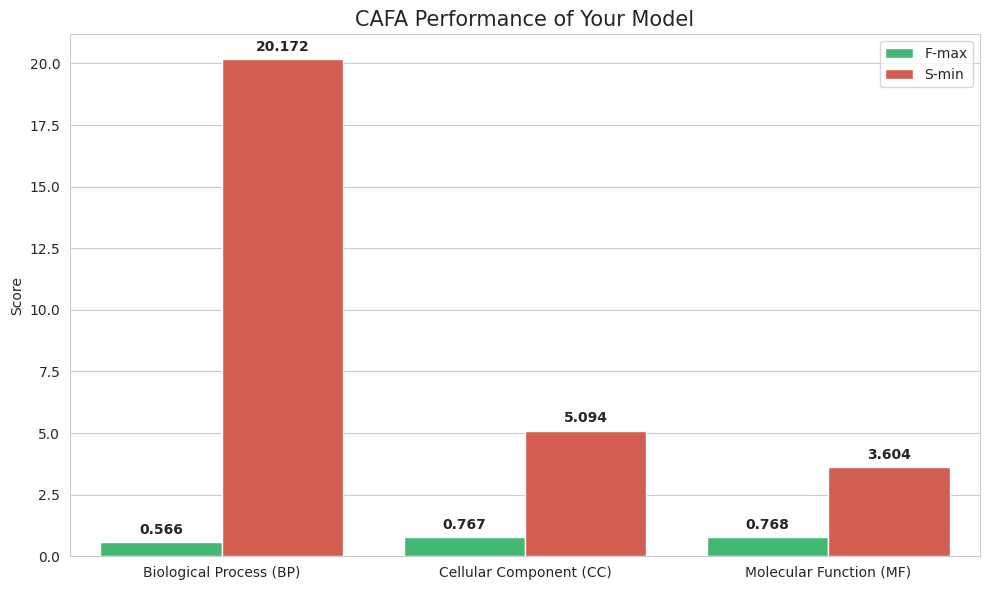

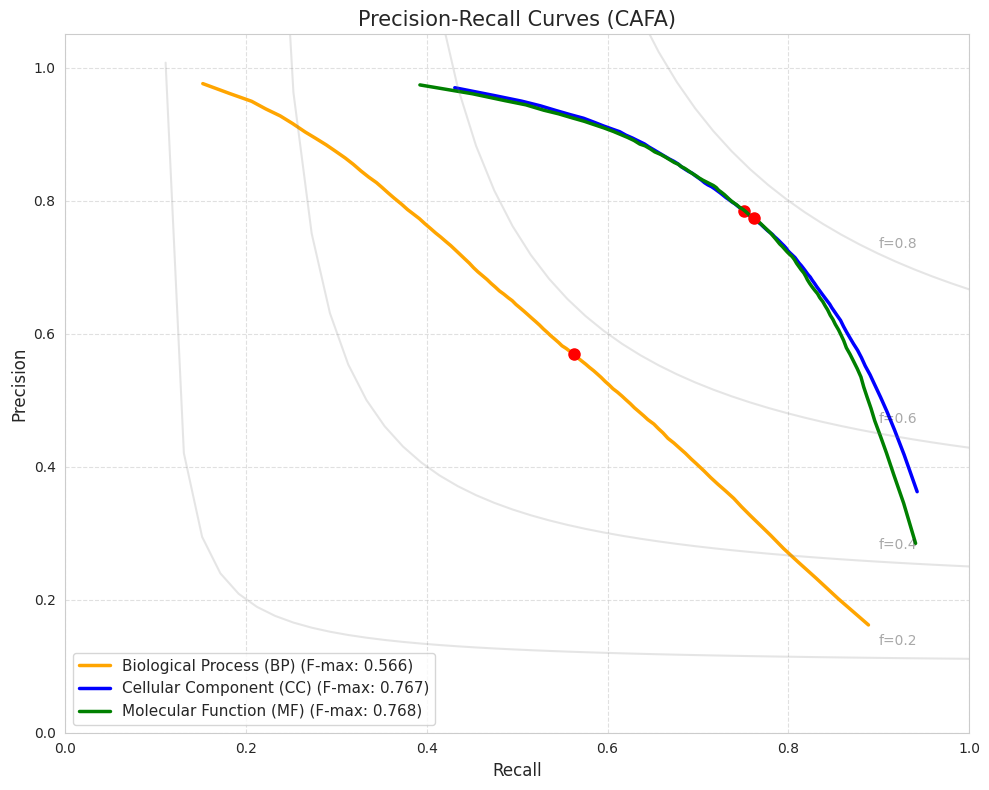

In [ ]:
# 1. Load data
df = pd.read_csv('cafa_results_summary.csv')

# 2. Ontology Mapping based on protein count (n)

n_to_ontology = {
    8464.0: 'Cellular Component (CC)',
    5570.0: 'Molecular Function (MF)',
    8307.0: 'Biological Process (BP)'
}

# Create a readable column
df['Ontology'] = df['n'].map(n_to_ontology)

df['Ontology'] = df['Ontology'].fillna('Unknown')

# Calculate best scores for each ontology
summary = df.groupby('Ontology').agg({
    'f': 'max',  # F-max (we want the maximum)
    's': 'min'   # S-min (we want the minimum)
}).reset_index()

# Melt data to plot them together
summary_melted = summary.melt(id_vars='Ontology', var_name='Metric', value_name='Score')
summary_melted['Metric'] = summary_melted['Metric'].map({'f': 'F-max', 's': 'S-min'})

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create Bar Plot
bp = sns.barplot(data=summary_melted, x='Ontology', y='Score', hue='Metric', palette=['#2ecc71', '#e74c3c'])

# Add numbers on top of bars
for p in bp.patches:
    if p.get_height() > 0: # Avoid zeros
        bp.annotate(format(p.get_height(), '.3f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontweight='bold')

plt.title('CAFA Performance of Your Model', fontsize=15)
plt.xlabel('')
plt.ylabel('Score')
plt.legend(title=None)
plt.tight_layout()
plt.savefig("cafa_summary_plot.png", dpi=300)
plt.show()

# --- PLOT 2: PRECISION-RECALL CURVES (Detailed) ---
plt.figure(figsize=(10, 8))

# Define colors for ontologies
colors = {'Cellular Component (CC)': 'blue',
          'Molecular Function (MF)': 'green',
          'Biological Process (BP)': 'orange'}

# Plot a curve for each ontology
for ontologia, group_data in df.groupby('Ontology'):
    if ontologia == 'Unknown': continue

    # Sort by Recall to get a clean line
    group_data = group_data.sort_values('rc')

    # Get Precision (pr) and Recall (rc)
    plt.plot(group_data['rc'], group_data['pr'],
             label=f"{ontologia} (F-max: {group_data['f'].max():.3f})",
             linewidth=2.5, color=colors.get(ontologia, 'black'))

    # Mark the F-max point on the curve with a dot
    best_point = group_data.loc[group_data['f'].idxmax()]
    plt.plot(best_point['rc'], best_point['pr'], 'o', color='red', markersize=8)

plt.title('Precision-Recall Curves (CAFA)', fontsize=15)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="lower left", fontsize=11)

# Add iso-F-measure curves
f_scores = np.linspace(0.2, 0.8, num=4)
for f in f_scores:
    x = np.linspace(0.01, 1)
    y = f * x / (2 * x - f)
    plt.plot(x[y >= 0], y[y >= 0], color='gray', alpha=0.2)
    plt.annotate('f={0:0.1f}'.format(f), xy=(0.9, y[45] + 0.02), alpha=0.4)

plt.tight_layout()
plt.savefig("precision_recall_curves.png", dpi=300)
plt.show()

# Naive baseline comparison


*   naive predictor definition (frequence based)
*   CAFA evaluation of the naive predictions



In [ ]:
def create_naive_predictions(y_train, mlb_classes, min_freq=0.01):
    """
    Calculates the frequency of each term in the training set.
    Returns a list of tuples (Term, Frequency) valid for ALL proteins.
    """
    # 1. Calculate mean frequency per column (Term)
    # y_train is a binary matrix (0/1). The mean is the frequency.
    term_frequencies = np.mean(y_train, axis=0)

    # 2. Create the list (Term, Frequency)
    naive_preds = []
    for i, freq in enumerate(term_frequencies):
        if freq >= min_freq: # ignore very rare terms
            naive_preds.append((mlb_classes[i], freq))

    # 3. Sort by descending frequency
    naive_preds.sort(key=lambda x: x[1], reverse=True)

    return naive_preds

print("Generating Naive Baseline...")

# Calculate frequencies for each ontology from TRAINING data
naive_list_cc = create_naive_predictions(y_trainCC, mlb_cc.classes_)
naive_list_bp = create_naive_predictions(y_trainBP, mlb_bp.classes_)
naive_list_mf = create_naive_predictions(y_trainMF, mlb_mf.classes_)

# Merge everything into a single global "Naive" list
naive_list_global = naive_list_cc + naive_list_bp + naive_list_mf
naive_list_global.sort(key=lambda x: x[1], reverse=True)
naive_list_global = naive_list_global[:1500] # CAFA Cutoff

naive_filename = "naive_submission.tsv"

# Combine all unique test IDs from the previous splits
test_protein_ids = set(ids_test_CC) | set(ids_test_BP) | set(ids_test_MF)
print(f"Assigning naive predictions to {len(test_protein_ids)} test proteins...")

with open(naive_filename, "w") as f:
    for pid in test_protein_ids:
        for term, score in naive_list_global:
            # Naive score is the frequency
            score = max(round(score, 3), 0.001)
            f.write(f"{pid}\t{term}\t{score:.3f}\n")

print(f"File {naive_filename} generated successfully.")

In [ ]:
# Define filenames
naive_filename = "naive_submission.tsv"
gt_filename = "ground_truth_cafa.tsv"

obo_file = training_data_path / "go-basic.obo"

# CAFAeval requires a directory, not a single file
naive_dir = "naive_predictions_folder"

if os.path.exists(naive_dir):
    shutil.rmtree(naive_dir) # Clean up if it already exists
os.makedirs(naive_dir)

# Copy the naive file into the directory
shutil.copy(naive_filename, os.path.join(naive_dir, "Naive_Model.tsv"))

res_naive = cafa_eval(obo_file, naive_dir, gt_filename)

df_naive = res_naive[0]
cols = [c for c in df_naive.columns if any(x in c.lower() for x in ['f', 's', 'rc', 'pr'])]
print(df_naive[cols].to_string())

# Save for comparison
df_naive.to_csv("cafa_results_naive.csv", index=False)
print("Results saved to 'cafa_results_naive.csv'")

                                                 fp         fn        pr        rc         f           s  pr_micro  rc_micro   f_micro
filename        ns                 tau                                                                                                
Naive_Model.tsv biological_process 0.01  553.903455   4.809558  0.046638  0.869022  0.088525  553.924335  0.046638  0.849259  0.088420
                                   0.02  291.623570   8.529674  0.074211  0.763414  0.135272  291.748286  0.074211  0.732663  0.134771
                                   0.03  204.722042  10.628145  0.094150  0.704961  0.166115  204.997736  0.094150  0.666893  0.165005
                                   0.04  150.602624  12.508728  0.114102  0.654093  0.194309  151.121205  0.114102  0.607952  0.192143
                                   0.05  116.177080  14.083183  0.133007  0.610679  0.218438  117.027560  0.133007  0.558605  0.214856
                                   0.06   91.559769  15

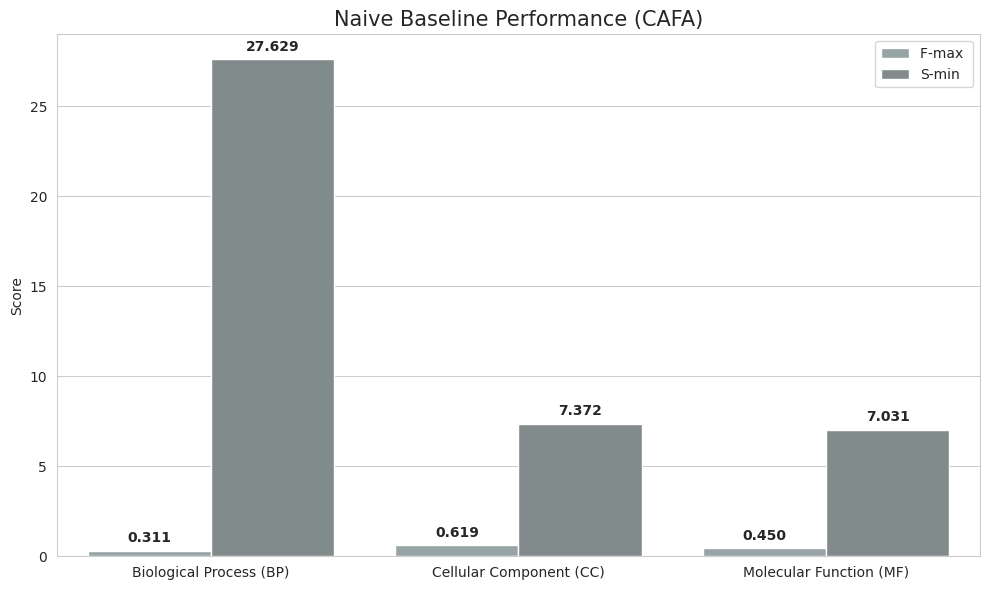

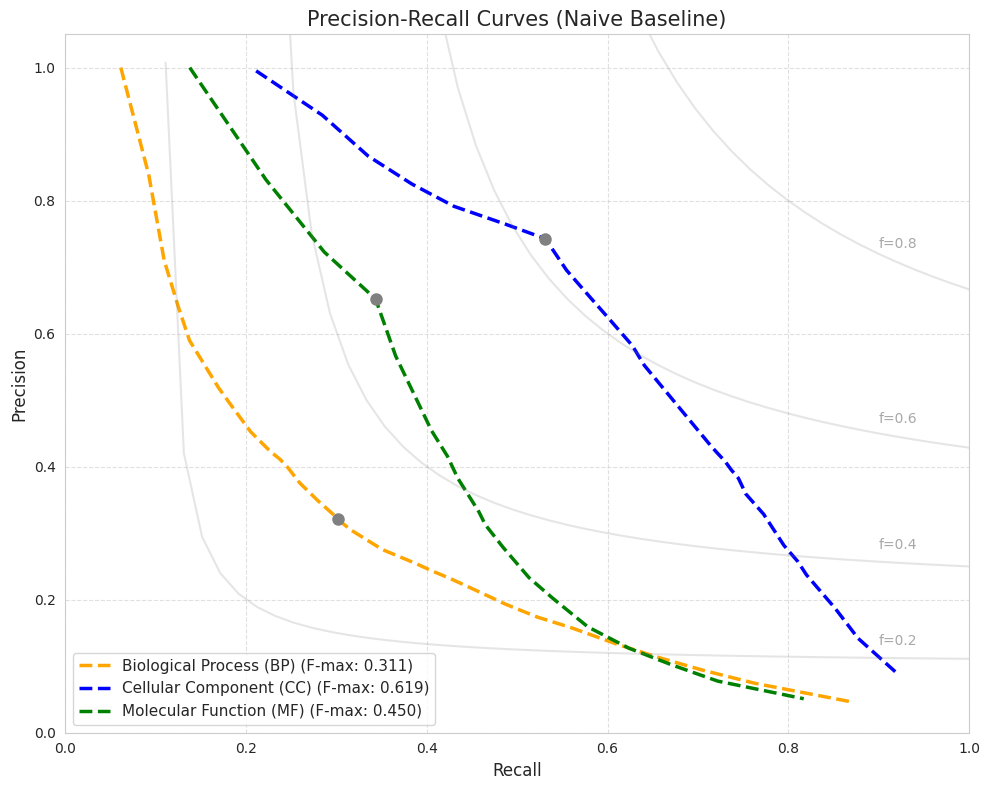

In [ ]:
# 1. Load Naive data
file_path = 'cafa_results_naive.csv'

if not os.path.exists(file_path):
    print(f"Error: File {file_path} not found.")
    print("Please run the Naive Evaluation step first.")
else:
    df = pd.read_csv(file_path)

    # 2. Ontology Mapping based on protein count (n)
    n_to_ontology = {
        8464.0: 'Cellular Component (CC)',
        5570.0: 'Molecular Function (MF)',
        8307.0: 'Biological Process (BP)'
    }

    # Create a readable column
    df['Ontology'] = df['n'].map(n_to_ontology)
    df['Ontology'] = df['Ontology'].fillna('Unknown')

    # --- PLOT 1: NAIVE METRICS SUMMARY (Bar Plot) ---
    summary = df.groupby('Ontology').agg({
        'f': 'max',  # F-max (Higher is better)
        's': 'min'   # S-min (Lower is better)
    }).reset_index()

    summary_melted = summary.melt(id_vars='Ontology', var_name='Metric', value_name='Score')
    summary_melted['Metric'] = summary_melted['Metric'].map({'f': 'F-max ', 's': 'S-min'})

    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    # Create Bar Plot
    bp = sns.barplot(data=summary_melted, x='Ontology', y='Score', hue='Metric', palette=['#95a5a6', '#7f8c8d']) # Grey tones for Naive

    # Add numbers on top of bars
    for p in bp.patches:
        if p.get_height() > 0:
            bp.annotate(format(p.get_height(), '.3f'),
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha = 'center', va = 'center',
                       xytext = (0, 9),
                       textcoords = 'offset points',
                       fontweight='bold')

    plt.title('Naive Baseline Performance (CAFA)', fontsize=15)
    plt.xlabel('')
    plt.ylabel('Score')
    plt.legend(title=None)
    plt.tight_layout()
    plt.savefig("naive_summary_plot.png", dpi=300)
    plt.show()

    # --- PLOT 2: NAIVE PRECISION-RECALL CURVES ---
    plt.figure(figsize=(10, 8))

    # Define colors for ontologies (using dashed lines/lighter colors for Naive usually)
    colors = {'Cellular Component (CC)': 'blue',
              'Molecular Function (MF)': 'green',
              'Biological Process (BP)': 'orange'}

    for ontologia, group_data in df.groupby('Ontology'):
        if ontologia == 'Unknown': continue

        # Sort by Recall
        group_data = group_data.sort_values('rc')

        # Plot curve
        plt.plot(group_data['rc'], group_data['pr'],
                 label=f"{ontologia} (F-max: {group_data['f'].max():.3f})",
                 linewidth=2.5, linestyle='--', color=colors.get(ontologia, 'black'))

        # Mark best point
        best_point = group_data.loc[group_data['f'].idxmax()]
        plt.plot(best_point['rc'], best_point['pr'], 'o', color='gray', markersize=8)

    plt.title('Precision-Recall Curves (Naive Baseline)', fontsize=15)
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc="lower left", fontsize=11)

    # Iso-F background lines
    f_scores = np.linspace(0.2, 0.8, num=4)
    for f in f_scores:
        x = np.linspace(0.01, 1)
        y = f * x / (2 * x - f)
        plt.plot(x[y >= 0], y[y >= 0], color='gray', alpha=0.2)
        plt.annotate('f={0:0.1f}'.format(f), xy=(0.9, y[45] + 0.02), alpha=0.4)

    plt.tight_layout()
    plt.savefig("naive_precision_recall_curves.png", dpi=300)
    plt.show()

# Comparison graphs

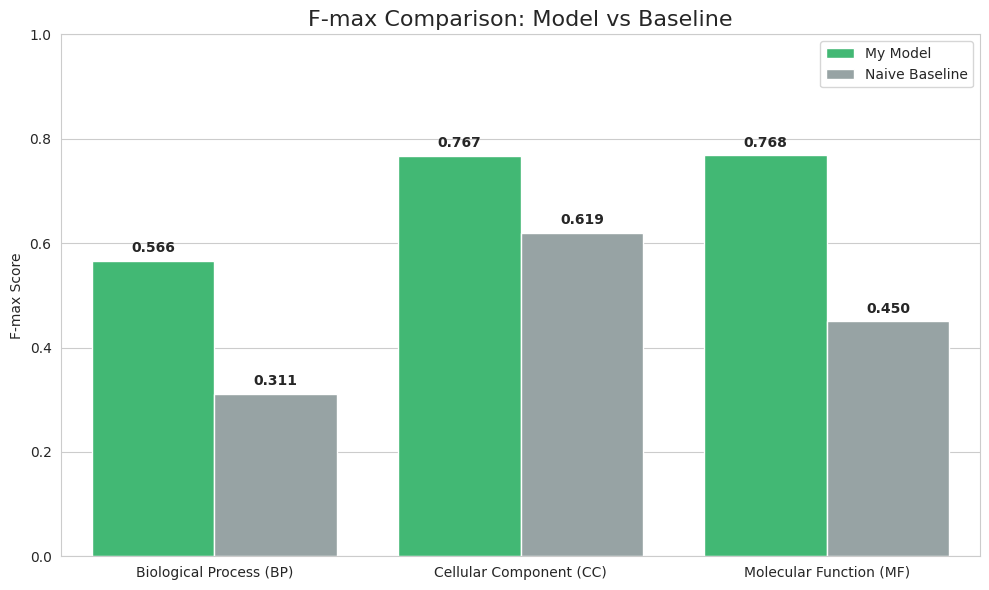

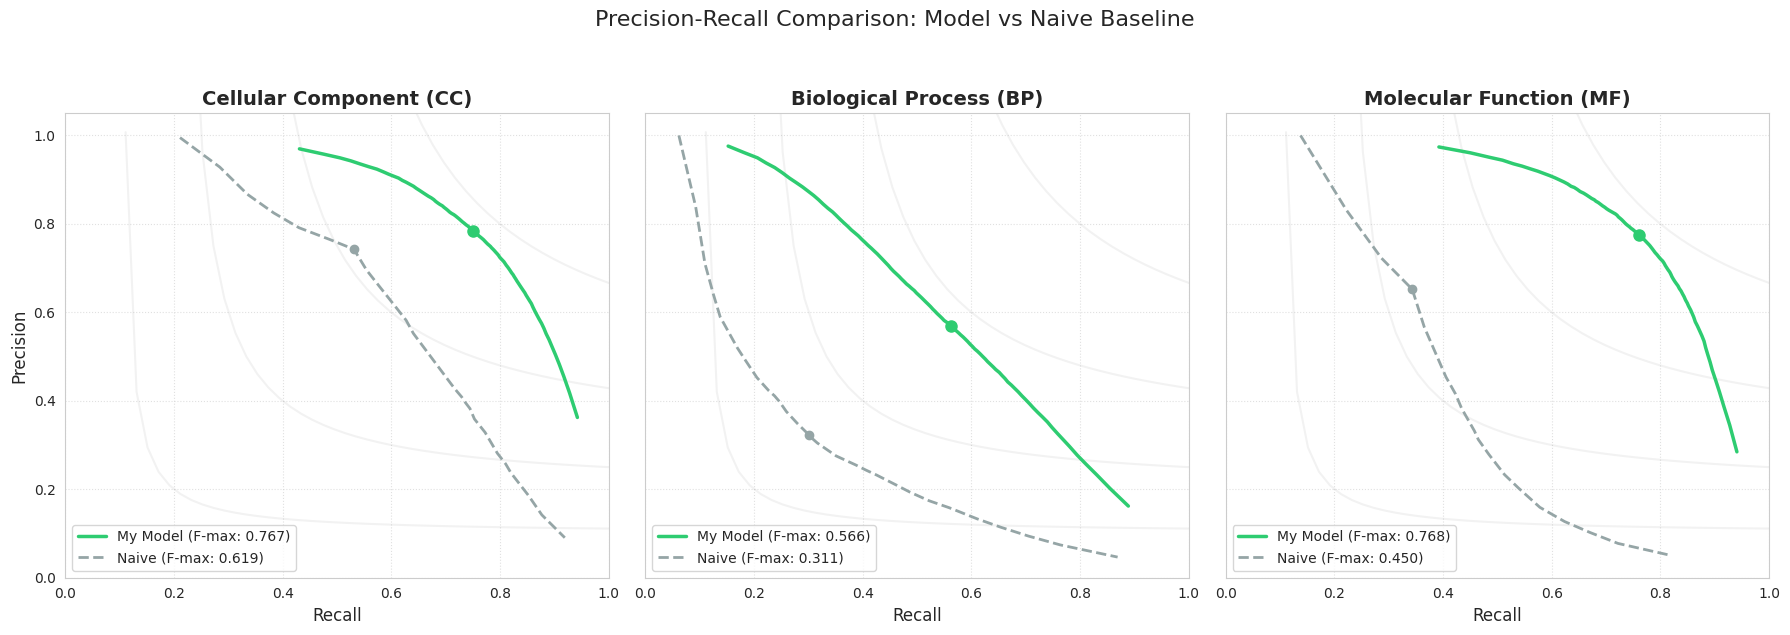

In [ ]:
model_file = 'cafa_results_summary.csv'
naive_file = 'cafa_results_naive.csv'

# Define your custom GREEN color here
my_model_color = '#2ecc71'  # Emerald Green
naive_color = '#95a5a6'     # Concrete Grey

# Check if files exist
if not os.path.exists(model_file):
    raise FileNotFoundError(f"Error: {model_file} not found!")

# Load Data
df_model = pd.read_csv(model_file)
df_model['Method'] = 'My Model'

if os.path.exists(naive_file):
    df_naive = pd.read_csv(naive_file)
    df_naive['Method'] = 'Naive Baseline'
    # Combine datasets
    df_all = pd.concat([df_model, df_naive])
else:
    df_all = df_model.copy()
    print("Plotting only the Model (Naive file missing).")

# Map the number of proteins (n) to the Ontology name
n_map = {
    8464.0: 'Cellular Component (CC)',
    5570.0: 'Molecular Function (MF)',
    8307.0: 'Biological Process (BP)'
}

df_all['Ontology'] = df_all['n'].map(n_map).fillna('Unknown')

# Calculate the best F-max for each method and ontology
summary = df_all.groupby(['Ontology', 'Method'])['f'].max().reset_index()

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create the grouped bar chart with GREEN palette
bp = sns.barplot(
    data=summary,
    x='Ontology',
    y='f',
    hue='Method',
    palette={'My Model': my_model_color, 'Naive Baseline': naive_color}
)

# Add scores on top of bars
for p in bp.patches:
    if p.get_height() > 0:
        bp.annotate(format(p.get_height(), '.3f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontweight='bold', fontsize=10)

plt.title('F-max Comparison: Model vs Baseline', fontsize=16)
plt.xlabel('')
plt.ylabel('F-max Score')
plt.legend(title=None, loc='upper right')
plt.ylim(0, 1.0)
plt.tight_layout()
plt.savefig("comparison_barplot_green.png", dpi=300)
plt.show()

# Create a figure with 3 subplots (one per ontology)
ontologies = ['Cellular Component (CC)', 'Biological Process (BP)', 'Molecular Function (MF)']
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, ont in enumerate(ontologies):
    ax = axes[i]

    # Filter data for the current ontology
    data_ont = df_all[df_all['Ontology'] == ont]

    if data_ont.empty:
        ax.set_title(f"{ont}\n(No Data)", fontsize=14)
        continue

    # 1. Plot Model Curve (GREEN Solid Line)
    model_data = data_ont[data_ont['Method'] == 'My Model'].sort_values('rc')
    if not model_data.empty:
        fmax = model_data['f'].max()
        ax.plot(model_data['rc'], model_data['pr'],
                label=f'My Model (F-max: {fmax:.3f})',
                color=my_model_color, linewidth=2.5, zorder=3)

        # Add a dot at the max F-score
        best_pt = model_data.loc[model_data['f'].idxmax()]
        ax.plot(best_pt['rc'], best_pt['pr'], 'o', color=my_model_color, markersize=8, zorder=4)

    # 2. Plot Naive Curve (Grey Dashed Line)
    naive_data = data_ont[data_ont['Method'] == 'Naive Baseline'].sort_values('rc')
    if not naive_data.empty:
        fmax = naive_data['f'].max()
        ax.plot(naive_data['rc'], naive_data['pr'],
                label=f'Naive (F-max: {fmax:.3f})',
                color=naive_color, linestyle='--', linewidth=2, zorder=2)

        # Add a dot
        best_pt = naive_data.loc[naive_data['f'].idxmax()]
        ax.plot(best_pt['rc'], best_pt['pr'], 'o', color=naive_color, markersize=6, zorder=4)

    # Graph Styling
    ax.set_title(ont, fontsize=14, fontweight='bold')
    ax.set_xlabel('Recall', fontsize=12)
    if i == 0: ax.set_ylabel('Precision', fontsize=12)

    ax.set_xlim(0, 1.0)
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower left', fontsize=10)

    # Add Iso-F background lines
    for f in np.linspace(0.2, 0.8, 4):
        x = np.linspace(0.01, 1)
        y = f * x / (2 * x - f)
        ax.plot(x[y >= 0], y[y >= 0], color='gray', alpha=0.1, zorder=1)

plt.suptitle("Precision-Recall Comparison: Model vs Naive Baseline", fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig("comparison_pr_curves.png", dpi=300, bbox_inches='tight')
plt.show()

# Comparison to baselines provided by the professor

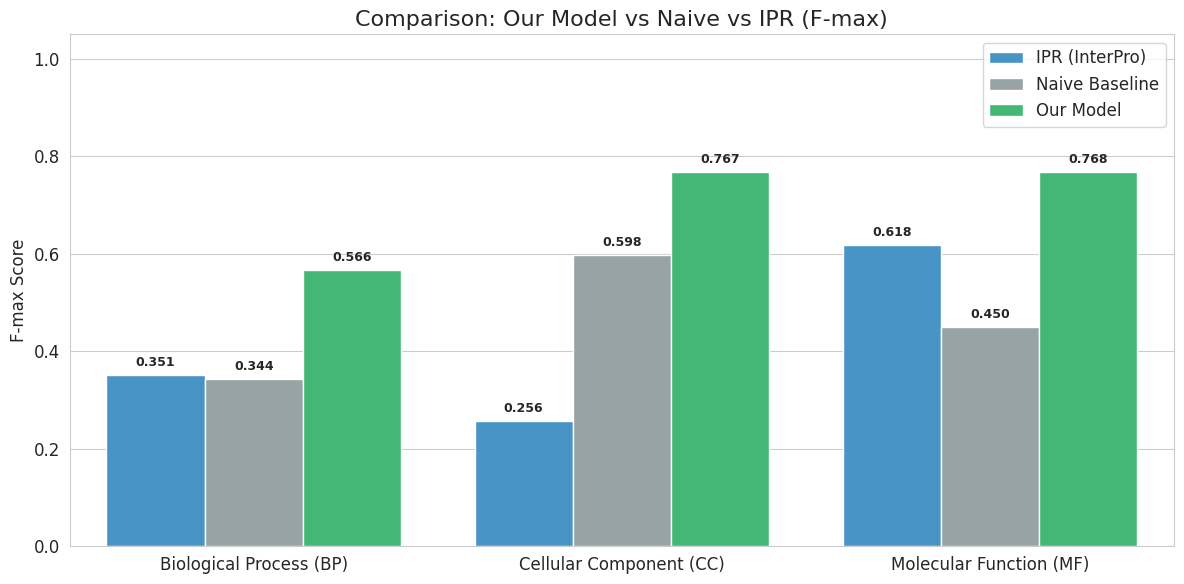

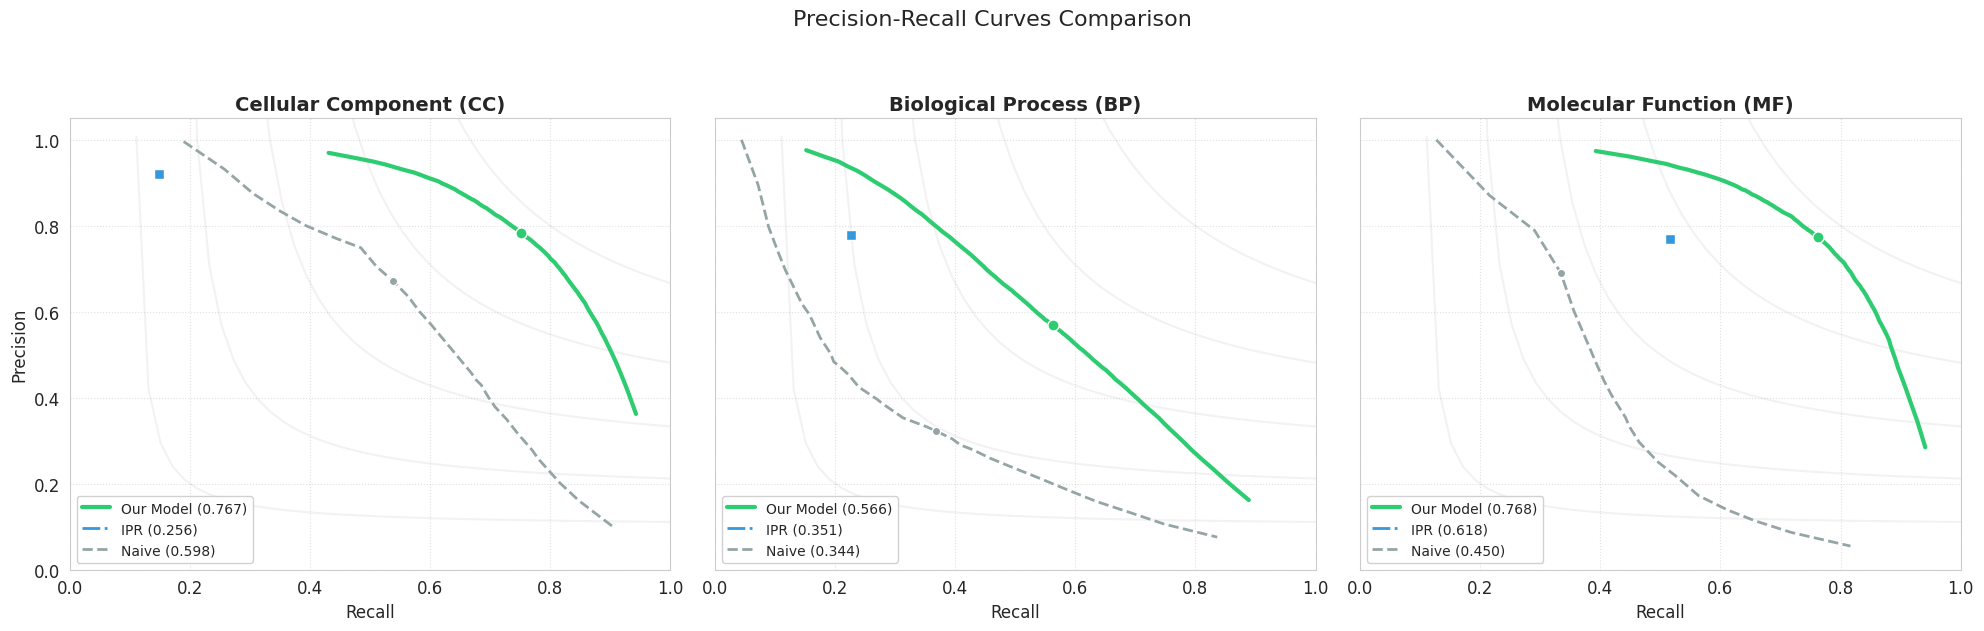

In [7]:
model_file = 'cafa_results_summary.csv'
eval_all_file = 'evaluation_all.tsv'  # Contains both IPR and Naive data

# Custom Colors
my_model_color = '#2ecc71'  # Emerald Green
naive_color = '#95a5a6'     # Concrete Grey
ipr_color = '#3498db'       # Bright Blue (For IPR)

# Map A: Based on protein count 'n' (for your local model CSV)
n_map = {
    8464.0: 'Cellular Component (CC)',
    5570.0: 'Molecular Function (MF)',
    8307.0: 'Biological Process (BP)'
}

# Map B: Based on string 'ns' (for the evaluation_all.tsv file)
ns_map = {
    'cellular_component': 'Cellular Component (CC)',
    'molecular_function': 'Molecular Function (MF)',
    'biological_process': 'Biological Process (BP)'
}

dfs = []

# A. Load "My Model" (Your local results)
if os.path.exists(model_file):
    df_model = pd.read_csv(model_file)
    df_model['Method'] = 'Our Model'

    # Use 'n' map if column exists, otherwise try 'ns'
    if 'n' in df_model.columns:
        df_model['Ontology'] = df_model['n'].map(n_map).fillna('Unknown')
    elif 'ns' in df_model.columns:
        df_model['Ontology'] = df_model['ns'].map(ns_map)

    # Ensure we only keep valid columns
    dfs.append(df_model)
else:
    print(f"Warning: {model_file} not found.")

# B. Load "Naive" and "IPR" from evaluation_all.tsv
if os.path.exists(eval_all_file):
    df_eval = pd.read_csv(eval_all_file, sep='\t')

    # Filter rows where filename contains 'ipr'
    df_ipr = df_eval[df_eval['filename'].str.contains('ipr', case=False, na=False)].copy()
    if not df_ipr.empty:
        df_ipr['Method'] = 'IPR (InterPro)'
        df_ipr['Ontology'] = df_ipr['ns'].map(ns_map)
        dfs.append(df_ipr)
    else:
        print("No IPR data found in evaluation_all.tsv")

    # Filter rows where filename contains 'naive'
    df_naive = df_eval[df_eval['filename'].str.contains('naive', case=False, na=False)].copy()
    if not df_naive.empty:
        df_naive['Method'] = 'Naive Baseline'
        df_naive['Ontology'] = df_naive['ns'].map(ns_map)
        dfs.append(df_naive)
    else:
        print("No Naive data found in evaluation_all.tsv")

else:
    print(f"File {eval_all_file} not found.")

# Unify all dataframes
if dfs:
    # Select only useful common columns
    cols_to_keep = ['Method', 'Ontology', 'f', 'rc', 'pr']
    df_all = pd.concat([d[cols_to_keep] for d in dfs], ignore_index=True)
else:
    raise ValueError("No data loaded! Check file paths.")

# --- 3. PLOT 1: BAR CHART (F-MAX) ---
# Calculate the best F-max for each method and ontology
summary = df_all.groupby(['Ontology', 'Method'])['f'].max().reset_index()

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Dynamic color palette
palette = {
    'Our Model': my_model_color,
    'Naive Baseline': naive_color,
    'IPR (InterPro)': ipr_color
}

bp = sns.barplot(
    data=summary,
    x='Ontology',
    y='f',
    hue='Method',
    palette=palette
)

# Add values on top of bars
for p in bp.patches:
    if p.get_height() > 0:
        bp.annotate(format(p.get_height(), '.3f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontweight='bold', fontsize=9)

plt.title('Comparison: Our Model vs Naive vs IPR (F-max)', fontsize=16)
plt.ylabel('F-max Score')
plt.xlabel('')
plt.legend(title=None, loc='upper right')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig("comparison_barplot_all_sources.png", dpi=300)
plt.show()

# --- 4. PLOT 2: PRECISION-RECALL CURVES ---
ontologies = ['Cellular Component (CC)', 'Biological Process (BP)', 'Molecular Function (MF)']
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for i, ont in enumerate(ontologies):
    ax = axes[i]
    data_ont = df_all[df_all['Ontology'] == ont]

    if data_ont.empty:
        ax.set_title(f"{ont}\n(No Data)", fontsize=14)
        continue

    # A. My Model
    model_data = data_ont[data_ont['Method'] == 'Our Model'].sort_values('rc')
    if not model_data.empty:
        fmax = model_data['f'].max()
        # Thick solid line
        ax.plot(model_data['rc'], model_data['pr'], label=f'Our Model ({fmax:.3f})',
                color=my_model_color, linewidth=3, zorder=5)
        # Dot marker
        best = model_data.loc[model_data['f'].idxmax()]
        ax.plot(best['rc'], best['pr'], 'o', color=my_model_color, markersize=8, zorder=6, markeredgecolor='white')

    # B. IPR
    ipr_data = data_ont[data_ont['Method'] == 'IPR (InterPro)'].sort_values('rc')
    if not ipr_data.empty:
        fmax = ipr_data['f'].max()
        # Dash-dot line
        ax.plot(ipr_data['rc'], ipr_data['pr'], label=f'IPR ({fmax:.3f})',
                color=ipr_color, linestyle='-.', linewidth=2, zorder=4)
        best = ipr_data.loc[ipr_data['f'].idxmax()]
        ax.plot(best['rc'], best['pr'], 's', color=ipr_color, markersize=7, zorder=6, markeredgecolor='white')

    # C. Naive
    naive_data = data_ont[data_ont['Method'] == 'Naive Baseline'].sort_values('rc')
    if not naive_data.empty:
        fmax = naive_data['f'].max()
        # Dashed line
        ax.plot(naive_data['rc'], naive_data['pr'], label=f'Naive ({fmax:.3f})',
                color=naive_color, linestyle='--', linewidth=2, zorder=3)
        best = naive_data.loc[naive_data['f'].idxmax()]
        ax.plot(best['rc'], best['pr'], 'o', color=naive_color, markersize=6, zorder=6, markeredgecolor='white')

    # Styling
    ax.set_title(ont, fontsize=14, fontweight='bold')
    ax.set_xlabel('Recall', fontsize=12)
    if i == 0: ax.set_ylabel('Precision', fontsize=12)
    ax.set_xlim(0, 1.0)
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower left', fontsize=10, frameon=True, framealpha=0.9)

    # Iso-F lines background
    for f in np.linspace(0.2, 0.8, 5):
        x = np.linspace(0.01, 1)
        y = f * x / (2 * x - f)
        ax.plot(x[y >= 0], y[y >= 0], color='gray', alpha=0.1, zorder=1)

plt.suptitle("Precision-Recall Curves Comparison", fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig("comparison_pr_curves_all_sources.png", dpi=300, bbox_inches='tight')
plt.show()